# Multi-Agent Systems: Patterns & Orchestration

**A 3-hour workshop notebook for mid-level ML Engineers**

**Stack:** OpenAI (GPT-4o / GPT-4o-mini) + Tavily web search + LangChain + LangGraph + Pydantic.

---

By the end of this notebook you will be able to:

1. Explain **why** multi-agent systems exist and when a single agent is enough.
2. Recognize the **six canonical multi-agent patterns** — Single Agent, Network, Supervisor, Supervisor-as-Tools, Hierarchical, Custom — and pick the right one for a given problem.
3. Build a **single-agent baseline** with OpenAI + Tavily, and compare it head-to-head with a multi-agent design.
4. Build a **3-agent research team** (Planner → Researcher → Writer) using LangGraph, with shared typed state, structured Pydantic outputs, source-quality classification, inline citations, and **real web search via Tavily**.
5. Convert a deterministic sequential graph into a **supervisor-routed graph** with feedback-driven re-research, hard guards, and an optional LLM-augmented variant.
6. **Stress-test** the system by simulating search failure and verify the safety net catches it.
7. Build a **runnable Swarm** with `langgraph-swarm` where agents hand off control to each other dynamically — and trace the handoff trail end-to-end.
8. Extend the team with a **Critic agent** (faithfulness + completeness scoring) and a **human-review node**.
9. **Debug** multi-agent systems: detect loops, validate outputs, log decisions, control termination, handle search failures.
10. Reason about **cost and latency** with a real `CostTracker` callback recording calls, tokens, and approximate dollars.

---

### Suggested time budget

| Section | Minutes |
|---|---|
| 1–3. Why / Patterns / Choosing | 30–40 |
| 4–5. Setup + single-agent baseline | 25–35 |
| 6. 3-agent research team (sequential) | 30–40 |
| 7. Supervisor (rule-based, LLM-aug, stress test) | 30–35 |
| 8. Real Swarm Demo (dynamic handoffs) | 20–25 |
| 9–10. Critic + human review | 20–25 |
| 11. Debugging | 10–15 |
| 12. Cost & latency walkthrough | 10–15 |
| 13. Exercises | 20–30 |

> **Instructor Note:** Don't skip Section 1. Most "multi-agent" production failures come from teams that should have built a single well-specified agent and instead built five agents that talk to each other badly.


---
## 1. Why multi-agent systems?

A *single agent* is just an LLM in a loop with some tools. You give it a system prompt, a user message, and a set of tools (`search`, `read_file`, `query_db`, ...). It picks tools, reads their outputs, picks more tools, and eventually returns an answer.

This works astonishingly well for a huge fraction of real problems. **Before adding more agents, ask: is the single agent actually failing, or am I being seduced by architecture?**

### When one agent is enough

A single tool-using agent is the right answer when:

- The task fits in one coherent role ("answer questions about our docs", "fix this Python bug").
- The number of tools is small (say, fewer than 10–15).
- There is no real specialization — every step uses similar reasoning.
- Latency matters. Every agent boundary is at least one extra LLM call.
- Debuggability matters. One agent = one trace. Five agents = five traces and a routing puzzle.

### When multi-agent earns its keep

You start to feel the pain of a single agent when:

- The **system prompt becomes a 4-page essay** trying to teach one model to be a planner, researcher, coder, writer, and critic at once. Capability collapse follows.
- **Tool count explodes.** Past ~20 tools, even good models start picking the wrong tool.
- The task has **genuinely different phases** that benefit from different prompts, different models, or different tool subsets.
- You need **isolation of context**. A research subagent can burn 50k tokens reading docs, then return a 500-token summary to the parent.
- Multiple **independent workstreams** can run in parallel.

### Common failure modes of "one giant agent"

- **Prompt bloat.** Every new requirement adds 3 lines to the system prompt. Six months in, the prompt is unreadable and contradictory.
- **Tool confusion.** With 30 tools, the model invokes `search_docs` when it should call `search_tickets`.
- **Context pollution.** Every tool result lands in the same context window. By turn 8, the original question is buried under 40k tokens of noise.
- **No specialization knob.** You can't say "use GPT-4o for the planning step and a small fast model for routing" — it's all one loop.

### Comparison

| | Single Agent | Multi-Agent |
|---|---|---|
| **Complexity** | Simpler to build, deploy, monitor | Multiple moving parts |
| **Latency** | Lower — one LLM loop | Higher — orchestration overhead |
| **Debugging** | One trace, one prompt | Routing decisions, handoff points, shared state |
| **Specialization** | Limited — one prompt does everything | Each agent can have its own prompt, model, tools |
| **Context isolation** | Everything shares one context | Subagents can isolate noisy work |
| **Coordination overhead** | None | Real — supervisor logic, termination conditions |
| **Best for** | Focused single-role tasks | Complex workflows with distinct phases |

> **Production Note:** A surprisingly large number of "we need multi-agent" requirements disappear after one round of prompt cleanup, tool consolidation, and adding structured outputs to a single agent. Try that first. We'll actually build a single-agent baseline in Section 5 so you can compare side-by-side.

> **Common Pitfall:** Building a multi-agent system because it sounds impressive, then watching it fail in QA because three agents argue with each other in a loop and burn $14 of tokens per request.


### The architecture landscape at a glance

<p align="center">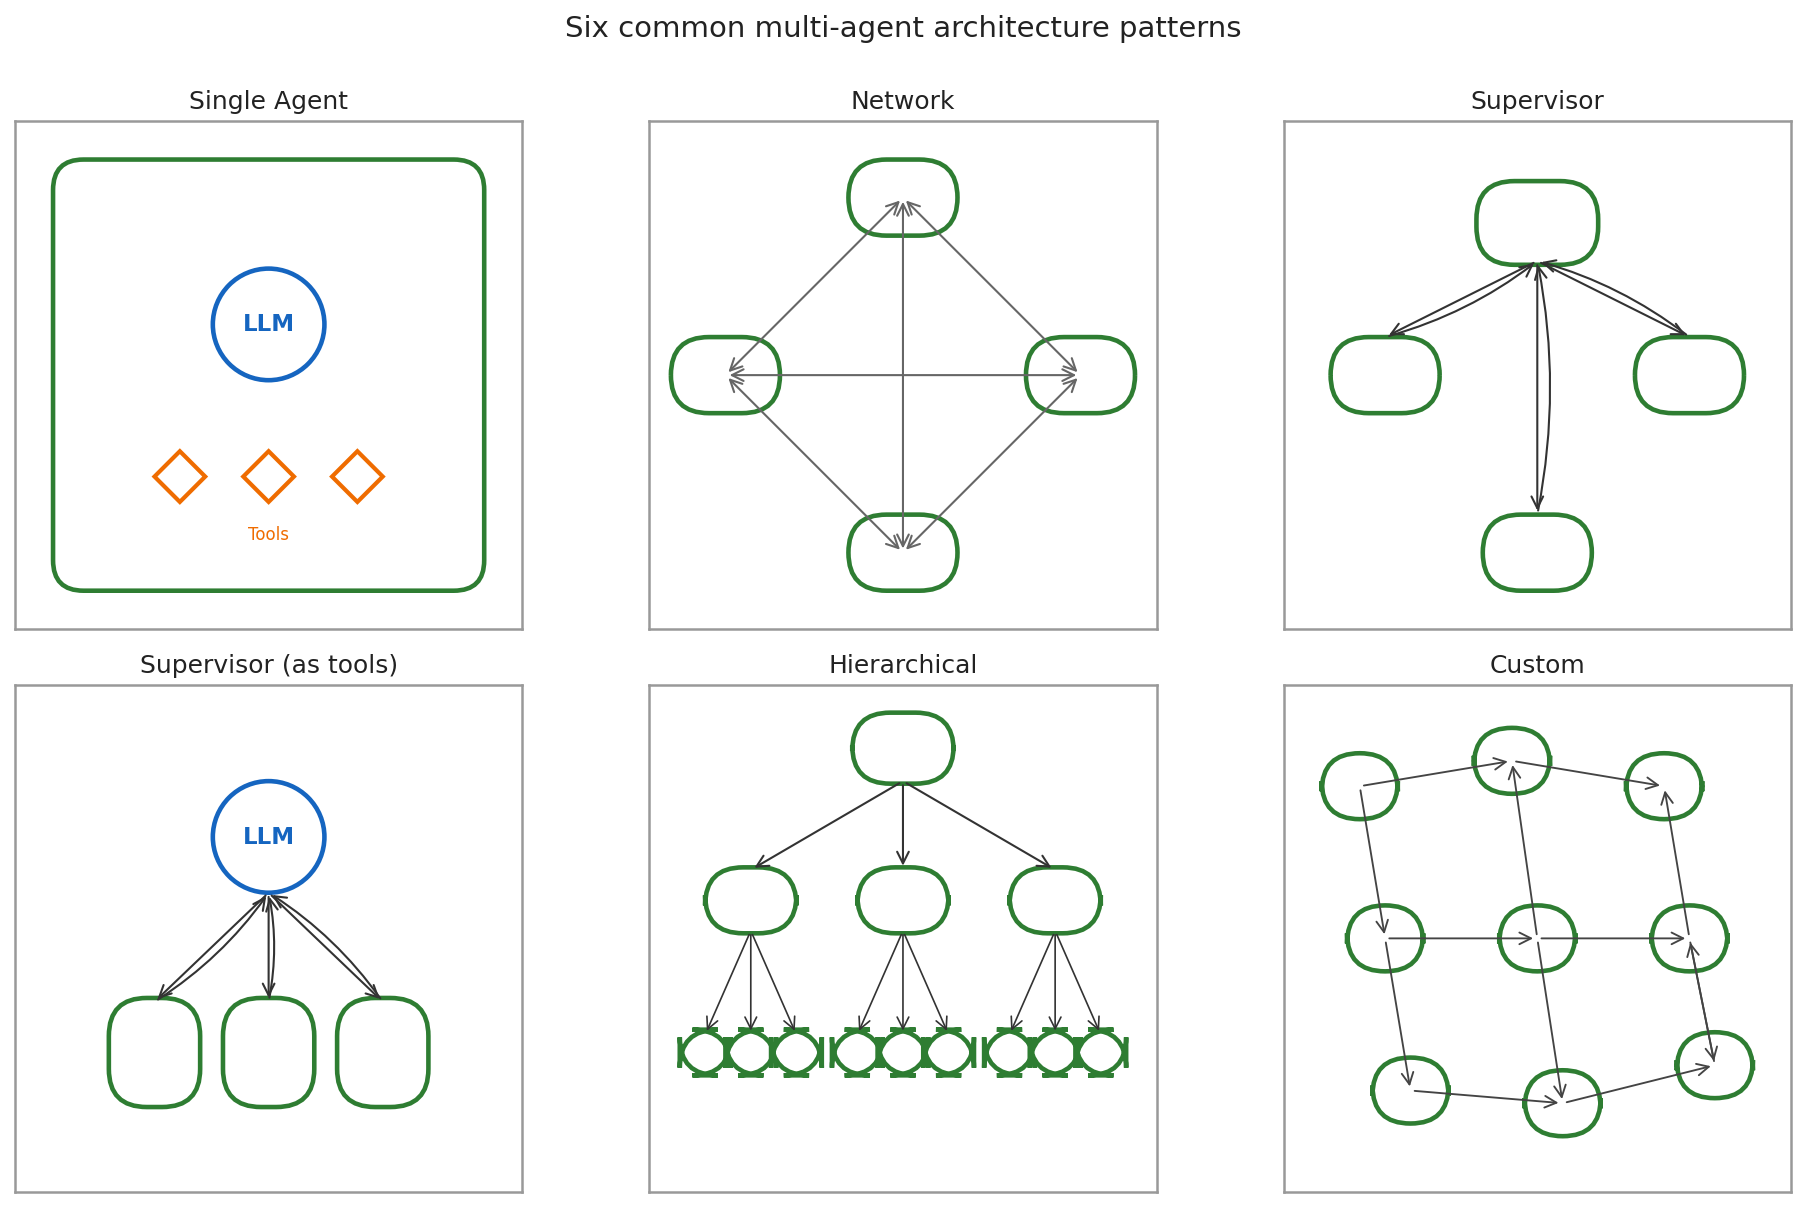</p>
<p align="center"><em>Six common multi-agent architecture patterns. Single Agent (top-left) is the baseline; everything else trades simplicity for some combination of specialization, autonomy, or scale.</em></p>

---
## 2. Multi-agent architecture patterns

We'll walk through each of the six patterns: what it is, when to use it, what makes it painful.


### 2A. Single Agent with Tools

One LLM, multiple tools, in a loop. The model decides which tool to call, reads the result, decides again. This is the baseline — every multi-agent design should be justified against it.


<p align="center">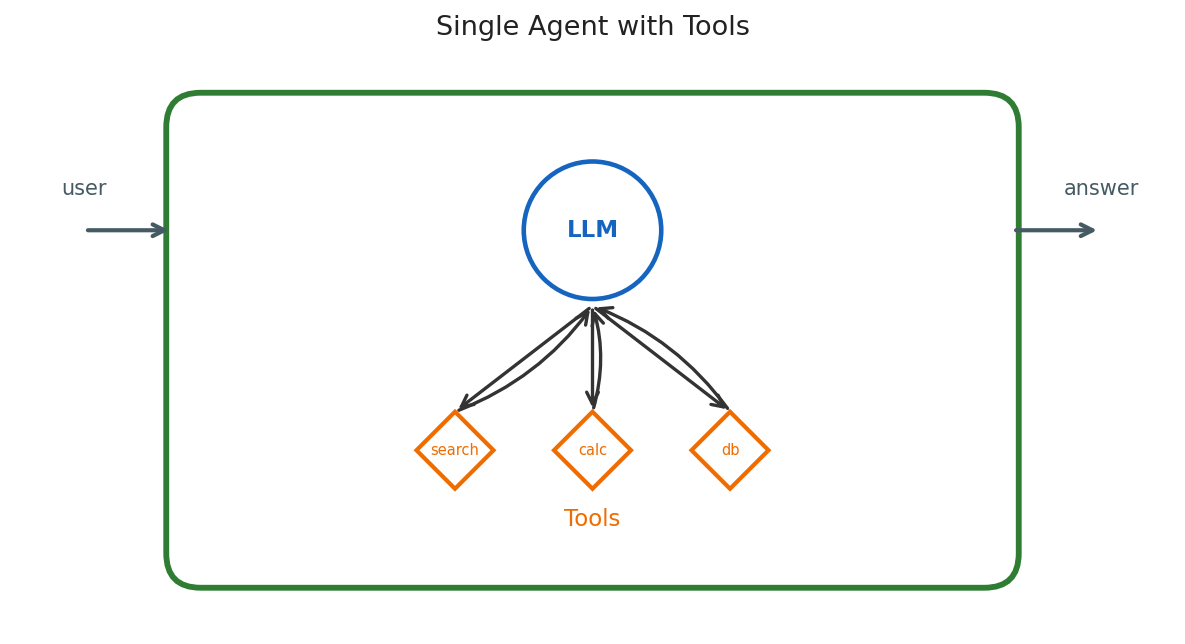</p>
<p align="center"><em>A single LLM agent calling tools in a loop. The agent owns all reasoning, planning, and synthesis.</em></p>

**Use this when:** task fits in one role; tool count is manageable; latency matters; you want easy debugging.
**Avoid when:** the prompt has become a textbook; the model picks wrong tools; you need to swap models per phase.


### 2B. Network Pattern

Multiple agents that can all talk to each other.


<p align="center">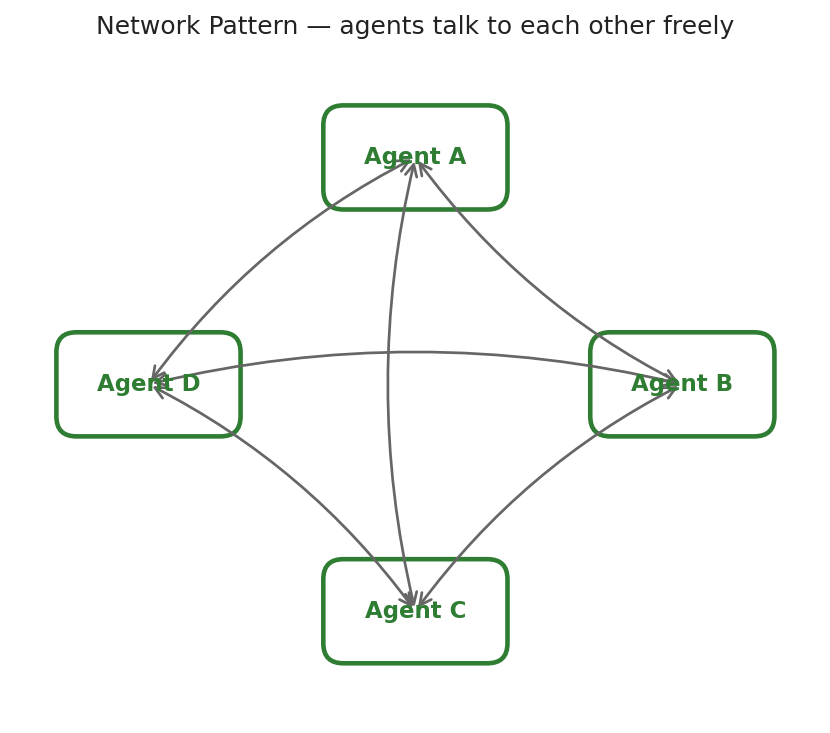</p>
<p align="center"><em>Network pattern: every agent can route to every other agent. Flexible, but coordination is fragile.</em></p>

**Use this when:** agents are genuinely peers and the conversation needs to flow organically; you have strong observability tooling.
**Avoid when:** you care about determinism, debuggability, or bounded cost. Network systems love to loop.

> **Common Pitfall:** Network patterns produce demos that look magical and production systems that page you at 2am because Agent A handed off to Agent B who handed back to Agent A 40 times before the iteration cap kicked in.


### 2C. Supervisor Pattern

A central supervisor agent decides which specialist runs next.


<p align="center">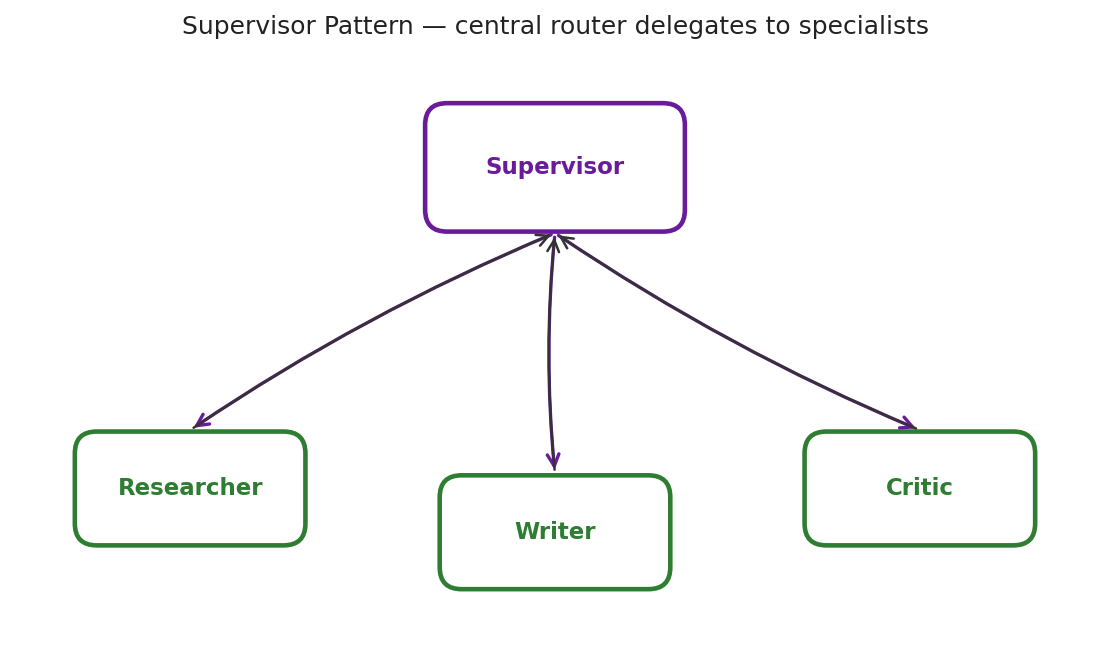</p>
<p align="center"><em>Supervisor pattern: a central router orchestrates specialized worker agents. Easy to debug because all routing decisions live in one place.</em></p>

**Use this when:** you have multiple specialized capabilities and need controlled routing. **This is the default production-grade choice for most multi-agent systems.**
**Watch out for:** every routing decision is an extra LLM call. 5 hops = 5 supervisor calls + 5 specialist calls = 10 LLM calls minimum.


### 2D. Supervisor-as-Tools

Same idea as Supervisor, but the specialists are exposed as **callable tools** to the supervisor LLM.


<p align="center">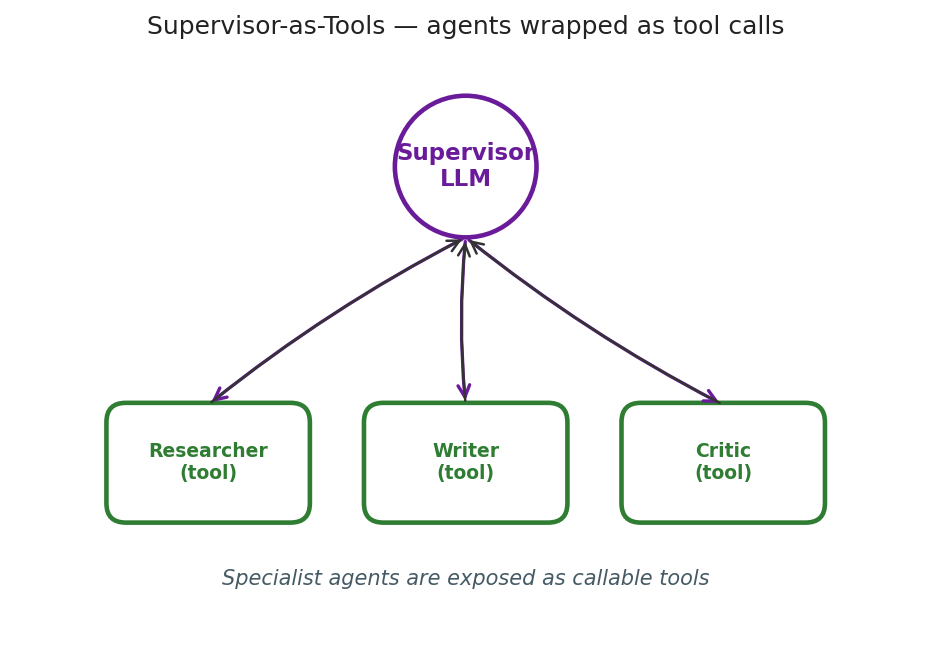</p>
<p align="center"><em>Supervisor-as-Tools: specialist agents are wrapped as tool functions the supervisor LLM can call directly.</em></p>

**Use this when:** you want a clean control boundary; the supervisor should always retain final say; you want to leverage native tool-calling rather than building your own router.
**Trade-off vs. plain Supervisor:** specialists are more isolated. The supervisor sees only their structured return value.


### 2E. Hierarchical Pattern

Supervisors of supervisors.


<p align="center">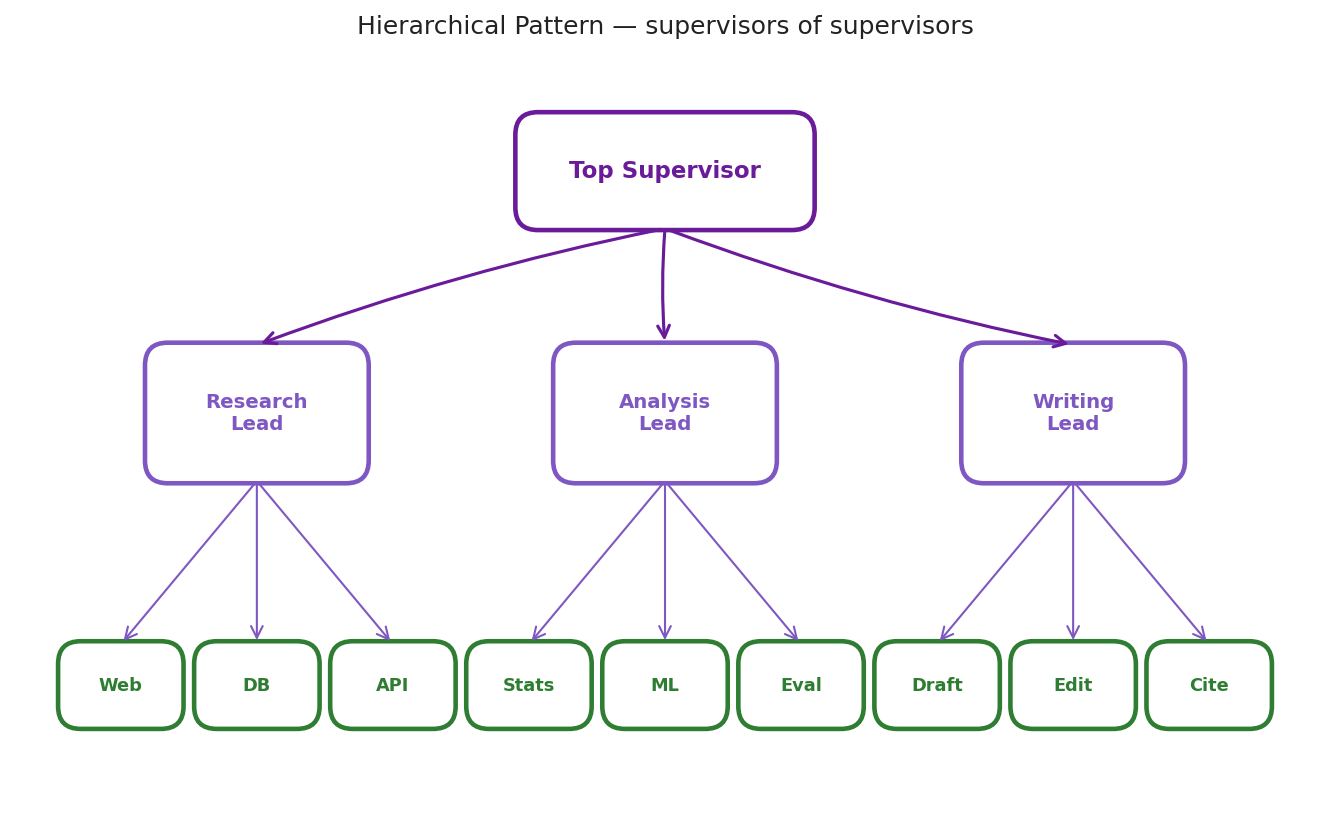</p>
<p align="center"><em>Hierarchical pattern: nested supervisors. Mirrors how real organizations split work across departments and sub-teams.</em></p>

**Use this when:** you have many agents (10+) and the work decomposes cleanly into sub-domains.
**Watch out for:** state and responsibility boundaries. Each level adds latency. Most teams should not start here.


### 2F. Custom Pattern

A hand-designed graph. Conditional edges, retries, validators, evaluators, human-review nodes — whatever the workflow needs.

**Use this when:** the workflow is well-understood and domain-specific. You want deterministic control flow with branching.

**This is what most production systems actually look like** once they mature. Pure pattern-A or pattern-B implementations are rare; real systems are hybrids tuned to their specific job.


### 2G. How agents actually communicate

Picking a pattern decides the *topology* of who talks to whom. But there are several distinct *mechanisms* through which agents actually exchange information. Most production systems mix two or three.

| Style | Mechanism | When it shines | What we use it for in this notebook |
|---|---|---|---|
| **Shared state** | Agents read/write fields on a typed graph state object | Pipelines where each step contributes a structured artifact | The 3-agent research team — Planner writes `plan`, Researcher writes `research_notes`, Writer reads both |
| **Message log** | Agents append to a running list of messages | Audit trails, conversational continuity, traceability | The `messages` field — every agent leaves a breadcrumb so we can reconstruct what happened |
| **Tool call** | One agent invokes another as a tool with structured args | Clean isolation; supervisor wants final control | The Supervisor-as-Tools pattern (2D) |
| **Handoff** | Active agent calls a `transfer_to_X` tool and control sticks with the new agent | Conversational ownership: triage → tech support → escalation | The swarm pattern (Section 8) |

> **Instructor Note:** "Which communication style?" is just as important a design question as "which topology?". A supervisor pattern with **shared state + structured tool returns** is very different in practice from a supervisor pattern that uses **only a message log** — the first is debuggable, the second is fragile.


---
## 3. Choosing the right pattern

```text
Use a Single Agent if:
  • The task is one coherent role
  • Tool count is small (<15)
  • No real specialization needed
  • Latency and simplicity matter

Use a Supervisor if:
  • Multiple specialized capabilities
  • Need controlled, debuggable routing
  • Want one place to change orchestration logic
  • This is your default production choice

Use Supervisor-as-Tools if:
  • You want native tool-calling for routing
  • Specialists should be isolated subtasks
  • Supervisor should retain final control of user-facing output

Use Handoffs / Swarm if:
  • Different agents own different parts of the conversation
  • The active agent should change over time

Use Hierarchical if:
  • You have many agents (10+)
  • Work decomposes into sub-teams

Use Custom LangGraph if:
  • Workflow structure is known
  • You need deterministic control with branching
  • You need retries, validators, checkpoints, human review
```

### Side-by-side comparison

| Pattern | Control | State sharing | Debuggability | Flexibility | Latency | Best for |
|---|---|---|---|---|---|---|
| **Single Agent** | Implicit (LLM loop) | Single context | Easy | Low | Lowest | Focused single-role tasks |
| **Network** | Distributed | Shared, all agents see all | Hard | Highest | Variable | Open-ended exploration (rare in prod) |
| **Supervisor** | Centralized | Shared via supervisor | Easy | Medium | Medium | Most production systems |
| **Supervisor-as-Tools** | Centralized | Isolated subtasks | Easy | Medium | Medium | Clean separation, native tool-calling |
| **Hierarchical** | Multi-level | Per-team + global | Medium | High | High | Large org-style workflows |
| **Custom** | Explicit (graph) | Designed | Easy (you wrote it) | High in theory, fixed in practice | Tunable | Mature production workflows |

> **Production Note:** "Start with the simplest pattern that could work, instrument it well, and measure before adding complexity" beats "design a hierarchical swarm on a whiteboard" 9 times out of 10.


---
## 4. Environment setup — OpenAI + Tavily

We will use:

- **OpenAI** as the LLM provider (`gpt-4o-mini` for routing/planning/extraction, `gpt-4o` for the synthesis-heavy Writer step).
- **Tavily** as the web search provider for the Researcher.
- **LangChain** for the LLM client and structured outputs.
- **LangGraph** for orchestration.
- **Pydantic** for typed state and structured agent outputs.

### Why OpenAI specifically?

- `gpt-4o-mini` has excellent structured output support (`with_structured_output`) and is cheap enough to use for routing and short structured extractions without thinking about cost.
- `gpt-4o` is strong at long-form synthesis — the right model for the Writer step where prose quality matters.
- Isolating models *per role* lets learners experiment with the cost/quality tradeoff without rewriting orchestration logic. Swap one constant, get a different price/quality point.

### Why Tavily?

Tavily is purpose-built for LLM agents: it returns clean, search-engine-grade snippets with URLs and titles, has an `advanced` search depth that produces denser context, and one short signup gets you free credits. It's the closest thing to "web search that just works in a notebook."


In [ ]:
# Install dependencies
%pip install -q langchain langgraph langchain-openai tavily-python pydantic

# Expected: a few "Successfully installed ..." lines.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 14.7 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key (free at tavily.com): ")

### Role-isolated model configuration

The whole point of multi-agent design is that different roles can use different models. We make that explicit by giving every role its own constant — change one line to swap the model for that role only.


In [ ]:
# --- Per-role model selection ---
# Cheap, fast model for routing decisions and structured extraction
MODEL_ROUTER     = "gpt-4o-mini"
MODEL_PLANNER    = "gpt-4o-mini"
MODEL_RESEARCHER = "gpt-4o-mini"

# Stronger model for the synthesis-heavy Writer step.
# Swap to "gpt-4o-mini" if you want a cheaper run during teaching.
MODEL_WRITER     = "gpt-4o"

# --- Optional: LangSmith tracing ---
# Tracing is invaluable for multi-agent debugging because it captures
# every prompt, every tool call, and every routing decision.
# Get a key at https://smith.langchain.com (free tier).
if "LANGSMITH_API_KEY" in os.environ:
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = "multi-agent-research-team"
    print("LangSmith tracing: ENABLED")
else:
    print("LangSmith tracing: disabled (set LANGSMITH_API_KEY to enable)")

### Cost tracking — a callback handler that watches every LLM call

We attach a single `CostTracker` callback to every LLM client. It records calls,
input/output tokens, and approximate cost — broken down by model. Tavily search
calls are tracked too. We'll use this in Section 10 to compare baseline vs.
sequential vs. supervisor side-by-side.


In [ ]:
from langchain_core.callbacks import BaseCallbackHandler

# Pricing per 1M tokens — keep this in one place so it's easy to update.
PRICING = {
    "gpt-4o-mini": {"in": 0.15, "out": 0.60},
    "gpt-4o":      {"in": 2.50, "out": 10.00},
}


class CostTracker(BaseCallbackHandler):
    """Counts LLM calls + tokens per model, plus Tavily search calls."""

    def __init__(self):
        self.calls_by_model     = {}   # model_name -> int
        self.in_tokens_by_model = {}
        self.out_tokens_by_model= {}
        self.tavily_calls       = 0

    def on_llm_end(self, response, **kwargs):
        for gen_list in response.generations:
            for gen in gen_list:
                msg = gen.message
                model = (getattr(msg, "response_metadata", {}) or {}).get("model_name", "unknown")
                # Strip date suffix like 'gpt-4o-mini-2024-07-18' -> 'gpt-4o-mini'
                model = "-".join(p for p in model.split("-") if not p.isdigit())
                self.calls_by_model[model] = self.calls_by_model.get(model, 0) + 1
                usage = getattr(msg, "usage_metadata", None) or {}
                self.in_tokens_by_model[model]  = self.in_tokens_by_model.get(model, 0)  + usage.get("input_tokens", 0)
                self.out_tokens_by_model[model] = self.out_tokens_by_model.get(model, 0) + usage.get("output_tokens", 0)

    @property
    def total_cost_usd(self) -> float:
        total = 0.0
        for model, in_t in self.in_tokens_by_model.items():
            out_t = self.out_tokens_by_model.get(model, 0)
            if model in PRICING:
                total += in_t  * PRICING[model]["in"]  / 1_000_000
                total += out_t * PRICING[model]["out"] / 1_000_000
        return total

    def summary(self) -> str:
        lines = ["Cost tracker summary:"]
        for model in sorted(self.calls_by_model):
            calls = self.calls_by_model[model]
            in_t  = self.in_tokens_by_model.get(model, 0)
            out_t = self.out_tokens_by_model.get(model, 0)
            lines.append(f"  {model}:  {calls} calls,  {in_t} in / {out_t} out tokens")
        lines.append(f"  Tavily search calls: {self.tavily_calls}")
        lines.append(f"  Estimated cost: ${self.total_cost_usd:.4f}")
        return "\n".join(lines)

    def snapshot(self) -> dict:
        """Plain dict snapshot at a moment in time — for diffing across runs."""
        return {
            "calls_by_model":     dict(self.calls_by_model),
            "in_tokens_by_model": dict(self.in_tokens_by_model),
            "out_tokens_by_model":dict(self.out_tokens_by_model),
            "tavily_calls":       self.tavily_calls,
            "cost_usd":           round(self.total_cost_usd, 4),
        }


cost_tracker = CostTracker()

In [ ]:
from langchain_openai import ChatOpenAI

# Each role gets its own LLM client. Temperatures are tuned per role:
#  • routing/planning/extraction → temperature=0 (deterministic, structured)
#  • writing → small positive temperature for fluent prose
# Every client is wired to the same cost_tracker so we get a unified view.
router_llm_base     = ChatOpenAI(model=MODEL_ROUTER,     temperature=0,   callbacks=[cost_tracker])
planner_llm_base    = ChatOpenAI(model=MODEL_PLANNER,    temperature=0,   callbacks=[cost_tracker])
researcher_llm_base = ChatOpenAI(model=MODEL_RESEARCHER, temperature=0,   callbacks=[cost_tracker])
writer_llm_base     = ChatOpenAI(model=MODEL_WRITER,     temperature=0.2, callbacks=[cost_tracker])

# Sanity check
print(router_llm_base.invoke("Reply with the single word: ready.").content)
# Expected: "ready" (or "Ready.")

### Tavily search — the real Researcher tool

The Researcher will issue real web queries via Tavily. We wrap the Tavily client in a small `tavily_search` function that returns a clean list of dicts, then add a `safe_search` wrapper that catches errors and a `mock_search` fallback for offline/airgapped classroom runs.


In [ ]:
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])


def tavily_search(query: str, k: int = 5) -> list[dict]:
    """Real web search via Tavily. Returns list of {title, url, snippet}."""
    response = tavily_client.search(
        query=query,
        max_results=k,
        search_depth="advanced",
        include_answer=False,
        include_raw_content=False,
    )
    return [
        {
            "title":   r.get("title", "Untitled"),
            "url":     r.get("url", ""),
            "snippet": r.get("content", ""),
        }
        for r in response.get("results", [])
    ]


# Mock fallback for offline classrooms / no API key
MOCK_CORPUS = {
    "rag long context tradeoffs": [
        {"title": "Long-context vs. RAG: an evaluation",
         "url":   "https://example.com/longctx-vs-rag",
         "snippet": "RAG matched a 200k-context model at ~30x lower cost. "
                    "Long-context models won on multi-hop reasoning where retrieval failed."},
        {"title": "Why retrieval still matters at 1M tokens",
         "url":   "https://example.com/retrieval-1m",
         "snippet": "Even with million-token windows, lost-in-the-middle effects persist."},
        {"title": "Enterprise QA: a cost analysis",
         "url":   "https://example.com/enterprise-qa-cost",
         "snippet": "Token cost dominates: a 200k-token prompt costs ~100x a 2k-token prompt."},
    ],
}

def mock_search(query: str, k: int = 3) -> list[dict]:
    q = query.lower()
    best_key = max(MOCK_CORPUS.keys(),
                   key=lambda key: len(set(q.split()) & set(key.split())))
    return MOCK_CORPUS[best_key][:k]


def safe_search(query: str, k: int = 5) -> list[dict]:
    """Tavily with graceful fallback. Never throws."""
    try:
        results = search_fn(query, k=k)
        cost_tracker.tavily_calls += 1
        return results
    except Exception as e:
        print(f"  [search-warning] '{query[:50]}...' failed: {e}")
        return []


# --- Choose your search backend ---
USE_MOCK_SEARCH = False   # set True to skip Tavily entirely

if USE_MOCK_SEARCH:
    search_fn = mock_search
    print("Search backend: MOCK")
else:
    search_fn = tavily_search
    print("Search backend: TAVILY (real web search)")

In [ ]:
# Quick smoke test — verify search works end-to-end
results = safe_search("RAG vs long-context LLM enterprise tradeoffs", k=3)
for r in results:
    print(f"- {r['title'][:80]}")
    print(f"  {r['url']}")
# Expected: 3 real URLs printed (or 3 example.com URLs in mock mode)

---
## 5. Baseline — a single agent with Tavily

Before we build a multi-agent team, let's build the **honest baseline**: one OpenAI model with the Tavily search tool, doing the whole job in a tool-calling loop. This is what we have to beat.


<p align="center">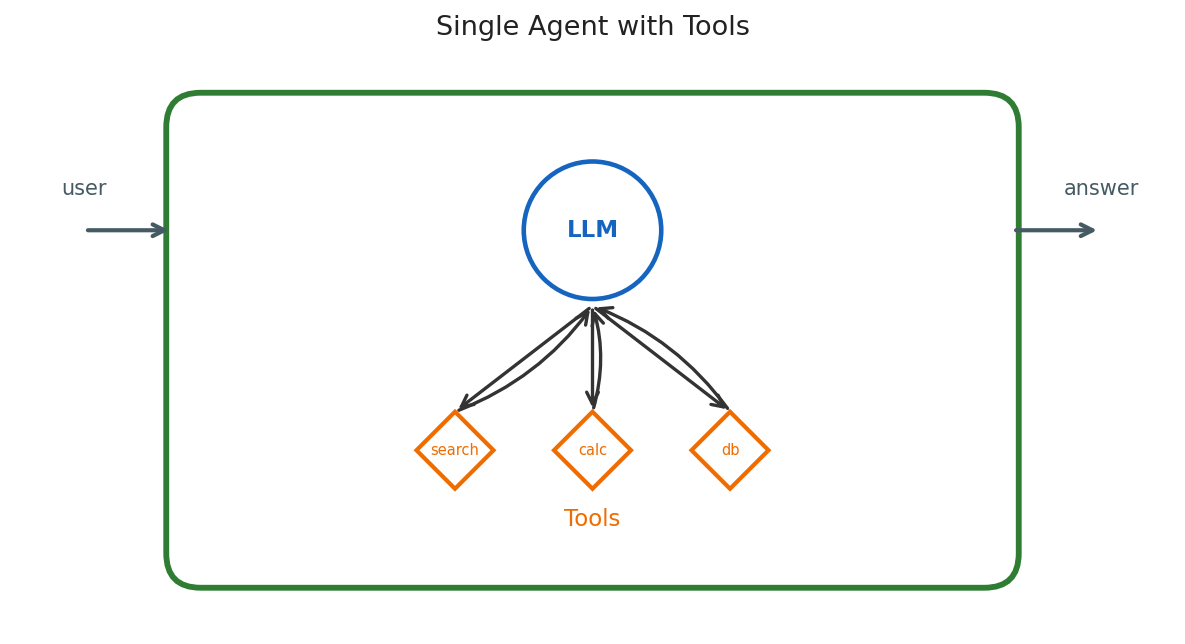</p>
<p align="center"><em>Single-agent baseline: one LLM with one tool (Tavily search), running in a tool-calling loop.</em></p>

In [ ]:
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

@tool
def web_search(query: str) -> str:
    """Search the web with Tavily. Returns up to 5 results as 'title :: url :: snippet'."""
    results = safe_search(query, k=5)
    if not results:
        return "No results."
    return "\n\n".join(
        f"{r['title']} :: {r['url']} :: {r['snippet']}" for r in results
    )

QUESTION = (
    "What are the current tradeoffs between RAG and long-context LLMs "
    "for enterprise question answering?"
)

**Why we write the ReAct loop ourselves instead of `create_react_agent`.**
The prebuilt helper is convenient, but writing the loop manually is exactly 12
readable lines and gives us three things at once: zero deprecation warnings, an
honest LLM-call count, and — most importantly — a clear view of what every other
"agent" in the notebook is doing under the hood. An "agent" is just an LLM that
can call tools in a loop until it stops calling tools. That's the whole concept.


In [ ]:
BASELINE_SYSTEM = (
    "You are a senior research analyst. Given a research question, "
    "search the web, gather evidence, and return a structured Markdown report "
    "with: a title, an executive summary, 2-4 sections with concrete claims, "
    "limitations, next steps, and a Sources list with clickable URLs. "
    "Cite sources by URL when making factual claims. Do not invent URLs."
)

def run_baseline(question: str, max_iters: int = 8):
    """Manual ReAct loop: one LLM, one tool, no framework."""
    llm = ChatOpenAI(model=MODEL_WRITER, temperature=0.2,
                     callbacks=[cost_tracker]).bind_tools([web_search])
    messages = [SystemMessage(content=BASELINE_SYSTEM),
                HumanMessage(content=question)]
    n_llm_calls = 0
    for _ in range(max_iters):
        response = llm.invoke(messages)
        n_llm_calls += 1
        messages.append(response)
        if not response.tool_calls:
            return response.content, n_llm_calls
        # Run every requested tool call and feed results back in.
        for tc in response.tool_calls:
            result = web_search.invoke(tc["args"])
            messages.append(ToolMessage(content=result, tool_call_id=tc["id"]))
    return response.content, n_llm_calls

In [ ]:
baseline_report, baseline_n_calls = run_baseline(QUESTION)
print(f"Baseline LLM calls: {baseline_n_calls}")
# Expected: 2-4 calls (search round(s) + final answer)

In [ ]:
from IPython.display import Markdown, display
display(Markdown(baseline_report))

**What the baseline gets you:** a respectable report from one prompt, one tool, one model. **What it doesn't give you:** structured intermediate artifacts you can inspect, the ability to swap a small model for the planning step and a larger one for the writing step, or a clean separation between "what to research" and "how to write it up."

We'll build the multi-agent version next and keep `baseline_n_calls` around for a head-to-head cost comparison at the end.


---
## 6. The 3-agent research team

Now we build the production-inspired version: Planner → Researcher → Writer, each with its own model, prompt, and structured output.


<p align="center">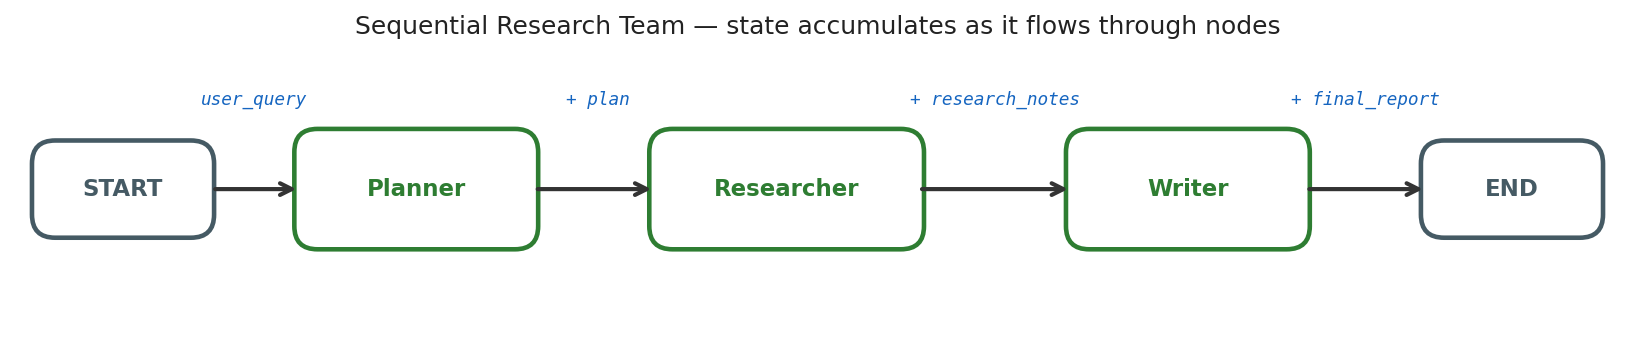</p>
<p align="center"><em>The sequential pipeline: each node reads from and writes to a shared typed state object.</em></p>

### 6.1 Structured outputs — the contract between agents

Structured outputs are the single most important reliability lever in multi-agent systems. They eliminate fragile string parsing, force each agent to produce a contract the next agent can rely on, and give you free Pydantic validation.


In [ ]:
from typing import Literal, Optional
from pydantic import BaseModel, Field


class ResearchPlan(BaseModel):
    """What the Planner produces."""
    topic: str = Field(description="The core topic in one sentence")
    objective: str = Field(description="What the final report should accomplish")
    sub_questions: list[str] = Field(
        description="3-6 specific sub-questions the researcher should answer",
        min_length=3, max_length=6,
    )
    required_evidence: list[str] = Field(
        description="What kinds of evidence/sources are needed (benchmarks, papers, vendor docs, etc.)"
    )
    expected_report_sections: list[str] = Field(
        description="Section headings the final report should contain"
    )


class SearchResult(BaseModel):
    """One row of search output, tagged with the sub-question that produced it."""
    query: str
    title: str
    url: str
    snippet: str


class EvidenceItem(BaseModel):
    """One claim with its source. Confidence and source quality are closed enums."""
    claim: str
    source_title: str
    source_url: str
    confidence: Literal["high", "medium", "low"]
    source_quality: Literal["primary", "technical_blog", "vendor", "marketing", "unknown"] = Field(
        description=(
            "Classify the source: 'primary' for papers/benchmarks/official docs/standards, "
            "'technical_blog' for engineering blogs from credible practitioners, "
            "'vendor' for company product pages and case studies, "
            "'marketing' for SEO/listicle content, 'unknown' if you cannot tell."
        )
    )


class ResearchNotes(BaseModel):
    """What the Researcher produces."""
    topic: str
    key_findings: list[str] = Field(description="Bullet-point findings, neutral and factual")
    evidence: list[EvidenceItem]
    open_questions: list[str] = Field(description="Things the researcher could not resolve")
    risks_or_uncertainties: list[str]


class ReportSection(BaseModel):
    heading: str
    body_markdown: str


class FinalReport(BaseModel):
    """What the Writer produces. Note that sources are first-class — every report carries its citations."""
    title: str
    executive_summary: str = Field(description="3-5 sentence summary for an executive reader")
    sections: list[ReportSection]
    limitations: list[str]
    next_steps: list[str]
    sources: list[EvidenceItem] = Field(
        description="Cited sources, each tied to a claim. Pull from research_notes.evidence; do not invent."
    )

### 6.2 Shared graph state

In LangGraph, state is the spine. Each node receives the state, returns a partial update, LangGraph merges.


<p align="center">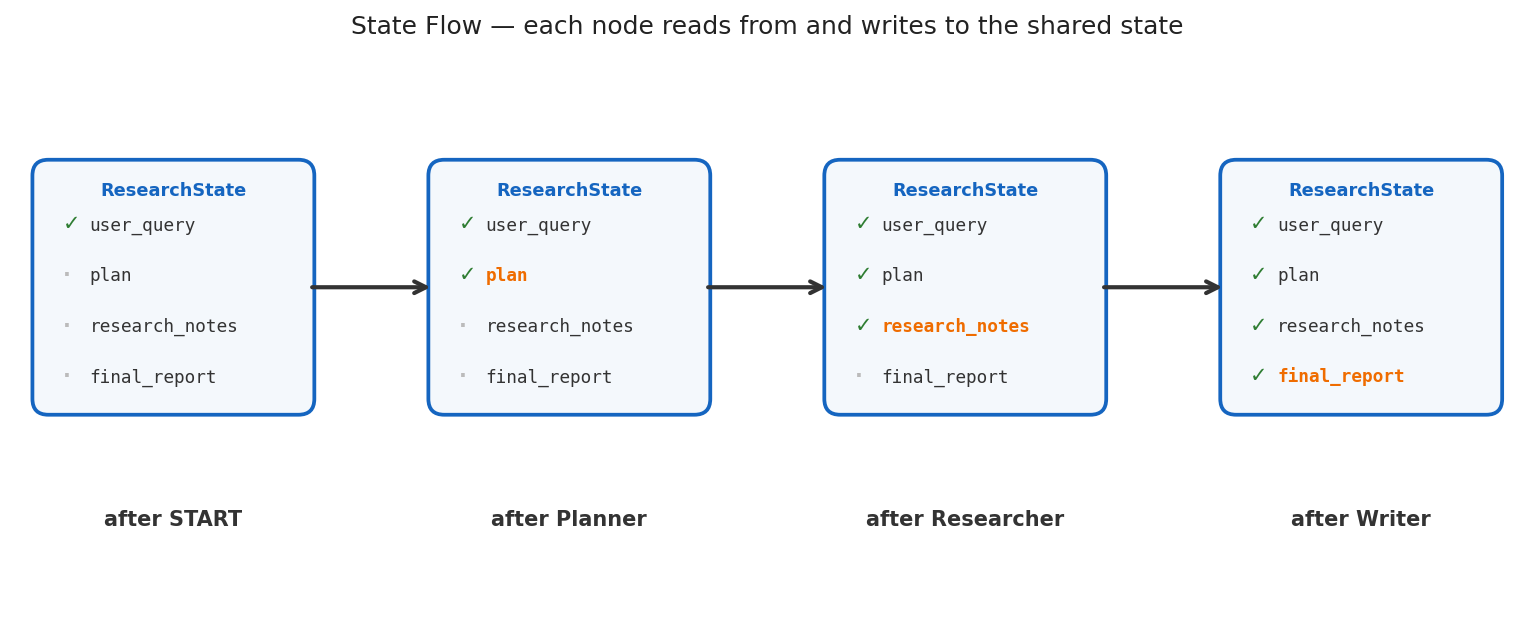</p>
<p align="center"><em>The shared ResearchState accumulates fields as it passes through nodes. Each agent only writes its own field.</em></p>

In [ ]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class ResearchState(TypedDict, total=False):
    user_query: str
    plan: Optional[ResearchPlan]
    research_notes: Optional[ResearchNotes]
    final_report: Optional[FinalReport]
    # Annotated with add_messages: each node returns just the NEW messages,
    # and LangGraph appends them. Without the reducer, returning a partial
    # list would replace the whole field — easy to lose history accidentally.
    messages: Annotated[list[BaseMessage], add_messages]
    # Bookkeeping
    n_llm_calls: int

> **Instructor Note — reducers are the right way to handle list state.** Without
> `add_messages`, every node that wanted to add a message would have to write
> `state.get("messages", []) + [new_msg]`. Forget the `+` and you've replaced the
> whole list. With the reducer, each node returns just the new messages and
> LangGraph merges them. Same pattern for any list-shaped state field
> (e.g. evidence accumulated across multiple researcher passes).


### 6.3 Planner

The Planner takes the raw query and produces a structured plan. It does **not** do the research itself — separation of concerns is the whole point.


In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

PLANNER_SYSTEM = """You are a meticulous research planner.
Your job is to take a user's research question and produce a structured plan.

Rules:
- Be specific. "Compare X and Y" -> list the exact dimensions to compare.
- 3 to 6 sub-questions. Each must be answerable with web evidence.
- required_evidence should name CONCRETE source types (benchmarks, papers, blog posts, vendor docs).
- Do NOT do the research yourself. Just plan.
"""

planner_llm = planner_llm_base.with_structured_output(ResearchPlan)


def planner_node(state: ResearchState) -> ResearchState:
    print("\n=== PLANNER ===")
    plan: ResearchPlan = planner_llm.invoke([
        SystemMessage(content=PLANNER_SYSTEM),
        HumanMessage(content=f"Research question: {state['user_query']}"),
    ])
    print(f"  topic: {plan.topic}")
    print(f"  sub_questions: {len(plan.sub_questions)}")
    return {
        "plan": plan,
        "messages": [
            AIMessage(content=f"[planner] produced plan with {len(plan.sub_questions)} sub-questions",
                      name="planner"),
        ],
        "n_llm_calls": state.get("n_llm_calls", 0) + 1,
    }

### 6.4 Researcher — with real Tavily search, dedup, and per-query tracking

The Researcher runs a Tavily search per sub-question, deduplicates by URL (the same source often appears under multiple queries), and produces structured notes that preserve which sub-question each source came from.


In [ ]:
def dedupe_results(results: list[SearchResult]) -> list[SearchResult]:
    """Drop duplicate URLs while preserving order and the first sub-question that found each."""
    seen, out = set(), []
    for r in results:
        if r.url and r.url not in seen:
            out.append(r)
            seen.add(r.url)
    return out


RESEARCHER_SYSTEM = """You are a careful research analyst.
You receive a research plan, a set of web search results, and possibly feedback
from a previous research pass. Your job: synthesize the results into structured
ResearchNotes.

Rules:
- Every key_finding should be supported by at least one EvidenceItem.
- Every EvidenceItem.source_url MUST appear in the search results provided.
  Do NOT invent URLs or sources.
- confidence: 'high' if multiple independent sources agree; 'medium' if one
  reputable source; 'low' if speculative or single weak source.
- source_quality: classify each source explicitly:
    * 'primary'        — peer-reviewed papers, official benchmarks, RFCs,
                         standards bodies, official product/API docs from
                         the project itself (e.g. arxiv.org, *.gov, official
                         repos, the project's own docs site).
    * 'technical_blog' — engineering posts from credible practitioners or
                         well-known engineering blogs (e.g. ai.googleblog,
                         engineering.fb, well-known personal blogs by
                         recognized researchers).
    * 'vendor'         — company product pages, case studies, sales-adjacent
                         content. Useful but biased.
    * 'marketing'      — SEO listicles, "Top 10" content, low-signal blog
                         farms. Treat with skepticism.
    * 'unknown'        — only if genuinely indeterminate.
- Web search is NOT automatically trustworthy. When evidence comes only from
  vendor/marketing sources, lower confidence to 'low' and call it out in
  risks_or_uncertainties.
- Be honest in open_questions about what you could not answer.
"""

researcher_llm = researcher_llm_base.with_structured_output(ResearchNotes)


def researcher_node(state: ResearchState) -> ResearchState:
    print("\n=== RESEARCHER ===")
    plan = state["plan"]
    feedback = state.get("research_feedback")  # set by supervisor on re-runs

    # Build query list. On a re-run, prepend a feedback-driven query.
    queries = list(plan.sub_questions)
    if feedback:
        queries = [f"{feedback} (related to: {plan.topic})"] + queries
        print(f"  [feedback] {feedback}")

    # Issue searches with per-sub-question tracking
    all_results: list[SearchResult] = []
    for q in queries:
        hits = safe_search(q, k=5)
        for h in hits:
            all_results.append(SearchResult(query=q, **h))
        print(f"  searched: {q[:70]}...  ({len(hits)} hits)")

    deduped = dedupe_results(all_results)
    print(f"  deduped to {len(deduped)} unique URLs (from {len(all_results)} raw)")

    if not deduped:
        # Defensive path: search returned nothing — produce empty notes
        # so downstream agents can gracefully degrade.
        notes = ResearchNotes(
            topic=plan.topic,
            key_findings=[],
            evidence=[],
            open_questions=[f"All searches returned zero results for: {plan.topic}"],
            risks_or_uncertainties=["No web evidence available"],
        )
    else:
        search_blob = "\n\n".join(
            f"[from sub-question: {r.query}]\n"
            f"TITLE: {r.title}\nURL: {r.url}\nSNIPPET: {r.snippet}"
            for r in deduped
        )
        notes: ResearchNotes = researcher_llm.invoke([
            SystemMessage(content=RESEARCHER_SYSTEM),
            HumanMessage(content=(
                f"Topic: {plan.topic}\n"
                f"Objective: {plan.objective}\n"
                f"Sub-questions:\n- " + "\n- ".join(plan.sub_questions) +
                (f"\n\nFeedback from previous pass: {feedback}" if feedback else "") +
                f"\n\nSearch results:\n{search_blob}"
            )),
        ])

    print(f"  -> {len(notes.key_findings)} findings, {len(notes.evidence)} evidence items, "
          f"{len(notes.open_questions)} open questions")

    return {
        "research_notes": notes,
        "research_feedback": None,  # consumed
        # NB: researcher_attempts is now incremented by the SUPERVISOR when it
        # dispatches to the researcher (see §7.4). Having two writers race on
        # one counter caused a real loop in v5 — the supervisor is the single
        # source of truth.
        "messages": [
            AIMessage(content=f"[researcher] attempt {state.get('researcher_attempts', 0)}: "
                              f"{len(notes.key_findings)} findings, {len(notes.evidence)} evidence",
                      name="researcher"),
        ],
        "n_llm_calls": state.get("n_llm_calls", 0) + 1,
    }

### 6.5 Writer — sources are first-class

The Writer pulls evidence from `research_notes` and emits a `FinalReport` whose `sources` field is grounded in the actual URLs the Researcher found. It must not invent URLs.


In [ ]:
WRITER_SYSTEM = """You are a senior technical writer.
Produce a clean, professional FinalReport from a research plan and notes.

Rules:
- The executive_summary must be readable in 30 seconds.
- Each report section should map to one of the plan's expected_report_sections.
- Pull concrete claims from research_notes.evidence. Do NOT invent claims or URLs.

CITATIONS — non-negotiable:
- Every factual claim in body_markdown that comes from a source MUST end with
  an inline citation in this exact form:  [Source Title]
  where 'Source Title' is the source_title of the EvidenceItem it came from.
- Multiple sources for one claim: [Source A; Source B]
- Do NOT use Markdown footnotes, numbered citations, or URL-only citations
  in the body. The Source Title goes in brackets right after the claim.
- The full URLs are rendered separately in the Sources section by the report
  template; you do not need to paste URLs in body text.

The sources list MUST be a faithful subset of research_notes.evidence — same URLs.
limitations must be honest: if the evidence base is small or skewed toward
vendor/marketing sources, say so.
"""

writer_llm = writer_llm_base.with_structured_output(FinalReport)


def writer_node(state: ResearchState) -> ResearchState:
    print("\n=== WRITER ===")
    plan = state["plan"]
    notes = state["research_notes"]

    report: FinalReport = writer_llm.invoke([
        SystemMessage(content=WRITER_SYSTEM),
        HumanMessage(content=(
            f"PLAN:\n{plan.model_dump_json(indent=2)}\n\n"
            f"NOTES:\n{notes.model_dump_json(indent=2)}"
        )),
    ])
    print(f"  title: {report.title}")
    print(f"  sections: {len(report.sections)}, sources: {len(report.sources)}")
    return {
        "final_report": report,
        "messages": [
            AIMessage(content=f"[writer] produced report '{report.title}' "
                              f"with {len(report.sections)} sections, {len(report.sources)} sources",
                      name="writer"),
        ],
        "n_llm_calls": state.get("n_llm_calls", 0) + 1,
    }

### 6.6 Wire up the LangGraph

Sequential graph: `START → planner → researcher → writer → END`. We extend `ResearchState` with the supervisor-related fields now so the same state type can be used for both the sequential and supervisor versions later.


In [ ]:
from langgraph.graph import StateGraph, START, END


class ResearchState(TypedDict, total=False):
    user_query: str
    plan: Optional[ResearchPlan]
    research_notes: Optional[ResearchNotes]
    final_report: Optional[FinalReport]
    messages: Annotated[list[BaseMessage], add_messages]
    n_llm_calls: int
    # Supervisor / loop control fields (used in Section 7)
    next_agent: str
    supervisor_reason: str
    research_feedback: Optional[str]
    researcher_attempts: int
    n_supervisor_steps: int


builder = StateGraph(ResearchState)
builder.add_node("planner", planner_node)
builder.add_node("researcher", researcher_node)
builder.add_node("writer", writer_node)

builder.add_edge(START, "planner")
builder.add_edge("planner", "researcher")
builder.add_edge("researcher", "writer")
builder.add_edge("writer", END)

graph = builder.compile()
print("Graph compiled with nodes:", list(builder.nodes.keys()))
# Expected: Graph compiled with nodes: ['planner', 'researcher', 'writer']

#### Render the compiled graph

LangGraph can render the compiled graph for you — useful for visually verifying that
edges and conditional routes are wired the way you intended. We'll do the same for
the supervisor graph later.


In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### 6.7 Run it

In [ ]:
initial_state: ResearchState = {
    "user_query": QUESTION,  # same question we used for the baseline
    "n_llm_calls": 0,
    "researcher_attempts": 0,
}

final_state = graph.invoke(initial_state)
print(f"\n=== DONE ===  Total LLM calls: {final_state['n_llm_calls']}")
# Expected: 3 LLM calls (planner + researcher + writer), plus N Tavily search calls

### 6.8 Render the final report (with sources!)

In [ ]:
QUALITY_MARKER = {
    "primary":        "🔬",  # peer-reviewed, official
    "technical_blog": "🛠️",  # credible engineering blog
    "vendor":         "🏢",  # company / product page
    "marketing":      "📣",  # SEO / listicle
    "unknown":        "❓",
}
CONFIDENCE_MARKER = {"high": "🟢", "medium": "🟡", "low": "⚪"}


def linkify_inline_citations(body: str, sources: list[EvidenceItem]) -> str:
    """Turn inline [Source Title] markers into clickable [Source Title](url).

    Walks the string character-by-character so we don't accidentally rewrite
    existing markdown links of the form [Text](url).
    Supports multi-source citations: [Source A; Source B] -> two links.
    """
    title_to_url = {s.source_title: s.source_url for s in sources}
    out = []
    i = 0
    while i < len(body):
        if body[i] == "[":
            j = body.find("]", i)
            # only rewrite if it's a [...] NOT immediately followed by (
            if j > 0 and (j + 1 >= len(body) or body[j + 1] != "("):
                inner = body[i + 1 : j]
                parts = [p.strip() for p in inner.split(";")]
                linked = [
                    (f"[{p}]({title_to_url[p]})" if p in title_to_url else f"[{p}]")
                    for p in parts
                ]
                out.append(", ".join(linked))
                i = j + 1
                continue
        out.append(body[i])
        i += 1
    return "".join(out)


def render_report(report: FinalReport) -> str:
    lines = [f"# {report.title}", "",
             "## Executive Summary",
             linkify_inline_citations(report.executive_summary, report.sources),
             ""]
    for sec in report.sections:
        lines += [f"## {sec.heading}",
                  linkify_inline_citations(sec.body_markdown, report.sources),
                  ""]
    lines += ["## Limitations"] + [f"- {x}" for x in report.limitations] + [""]
    lines += ["## Next Steps"] + [f"- {x}" for x in report.next_steps] + [""]
    lines += ["## Sources"]
    for src in report.sources:
        cm = CONFIDENCE_MARKER[src.confidence]
        qm = QUALITY_MARKER[src.source_quality]
        lines.append(f"- {qm} {cm} [{src.source_title}]({src.source_url}) — {src.claim}")
    lines += ["",
              "_Legend: confidence_  🟢 high  🟡 medium  ⚪ low &nbsp;&nbsp; "
              "_quality_  🔬 primary  🛠️ technical blog  🏢 vendor  📣 marketing  ❓ unknown"]
    return "\n".join(lines)


display(Markdown(render_report(final_state["final_report"])))

### 6.9 Inspect the structured intermediates

The whole point of structured outputs is that you can inspect every step.

In [ ]:
print("=" * 60); print("PLAN"); print("=" * 60)
print(final_state["plan"].model_dump_json(indent=2))

In [ ]:
print("=" * 60); print("RESEARCH NOTES"); print("=" * 60)
print(final_state["research_notes"].model_dump_json(indent=2)[:3000], "...")

---
## 7. Supervisor-style orchestration

The sequential graph is **deterministic**. But many real workflows aren't — sometimes the Researcher's first pass is thin and we want to send it back with specific feedback. That's the supervisor's job.


<p align="center">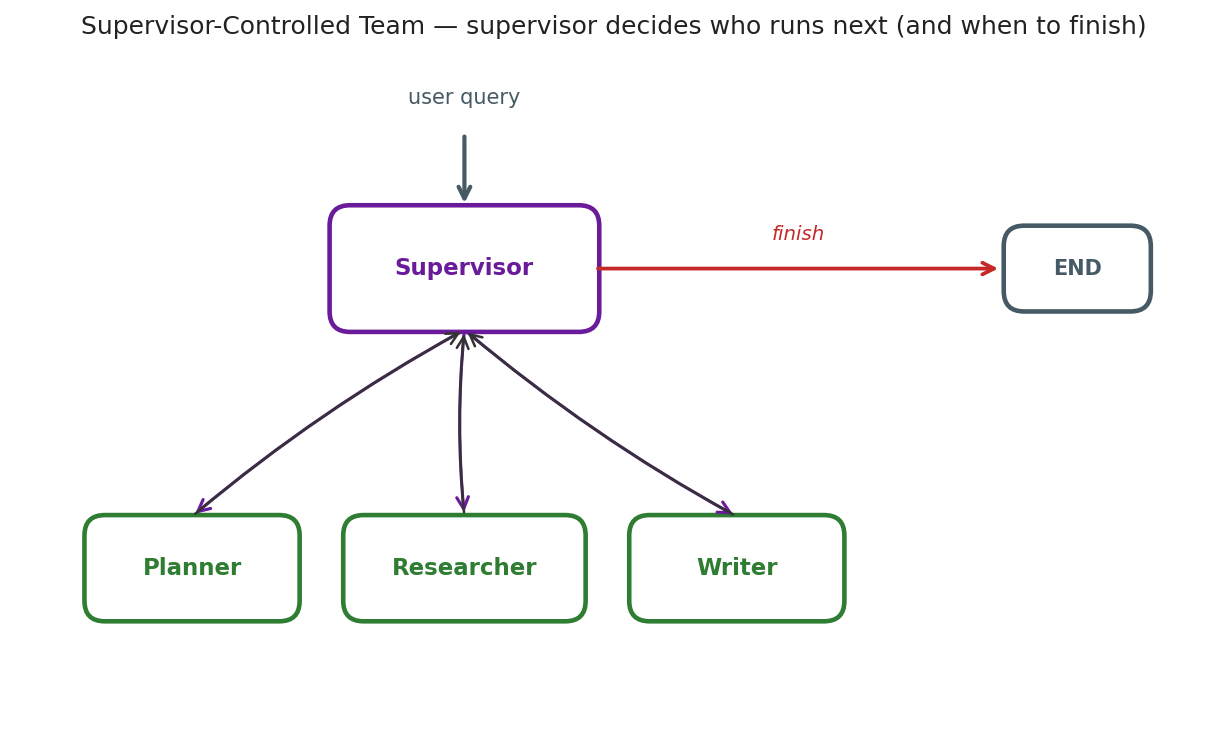</p>
<p align="center"><em>Supervisor-controlled team: control returns to the supervisor after every specialist run, and the supervisor decides whether to call another specialist or finish.</em></p>

### 7.1 Sequential vs. supervisor

| | Sequential | Supervisor |
|---|---|---|
| Control flow | Hard-coded edges | Supervisor decides each step |
| LLM calls | N (one per specialist) | ~2N (routing call + specialist call per step) |
| Flexibility | Fixed pipeline | Can revisit, skip, retry |
| When to use | Pipeline is genuinely fixed | Pipeline depends on intermediate results |

> **Production Note:** Supervisor adds roughly 2x the LLM calls of a sequential pipeline. Use a small fast model for routing.


### 7.2 The supervisor's decision schema

The supervisor outputs a structured decision: which agent runs next, an explanation, and (when sending the Researcher back) specific feedback.


In [ ]:
class SupervisorDecision(BaseModel):
    next_agent: Literal["planner", "researcher", "writer", "finish"]
    reason: str = Field(description="One sentence: why this agent next?")
    research_feedback: Optional[str] = Field(
        default=None,
        description="If routing back to researcher, specific gaps to fill. Else null.",
    )

### 7.3 A real failure trace — and what it teaches us

Here is a real (lightly trimmed) trace from running this notebook with a *purely LLM-based* supervisor whose prompt said "if `open_questions > 2`, consider routing back to researcher":

```
[SUPERVISOR] -> writer    (notes have too many open questions, but cap reached)
=== WRITER ===  produced report

[SUPERVISOR] -> researcher  (more than 2 open questions, need more evidence)
=== RESEARCHER ===  -> 5 findings, 5 evidence items, 3 open questions
[SUPERVISOR] -> researcher  (more than 2 open questions...)
=== RESEARCHER ===  -> 5 findings, 5 evidence items, 3 open questions
[SUPERVISOR] -> researcher  (more than 2 open questions...)
... and so on until GraphRecursionError
```

Three things failed simultaneously:

1. **The trigger never clears.** "Open questions" is the researcher's *honest disclosure* — the model will always list a few. Re-running the same Tavily queries against the same plan gives the same notes. So "open_questions > 2" is a self-perpetuating rule: it fires, we re-research, we get the same `3` open questions, it fires again.

2. **The graph let routing go backwards after the report existed.** Once `final_report` was set, going back to `researcher` was meaningless (there's no critic loop, no second-writer pass). The supervisor's prompt didn't forbid it loudly enough.

3. **The "defensive override" relied on a counter that wasn't enough.** `researcher_attempts` was at 1 when the report finished, and `1 < MAX = 2` permitted one more researcher run. The cap was too loose for a graph that has no business going backwards at all.

**The lesson:** soft constraints in a prompt are not constraints. A model can rationalize past any rule you put in English. Loop protection has to live in **code**, not in a system message. We're going to fix this with three changes:

- **Drop `open_questions > 2`** as a re-research trigger entirely. The only legitimate signal for re-research is "the notes are essentially empty."
- **Forbid going backwards from a finished report.** Once `final_report` exists, the only legal next step is `finish`.
- **Add an absolute step cap** (`MAX_SUPERVISOR_STEPS`) that fires regardless of what the supervisor decides.

Once you do all three, the routing decisions are no longer genuinely ambiguous — so the supervisor can be **rule-based** (no LLM call). That's the right answer for *this* graph. We'll keep an LLM-augmented variant at the end of the section for cases where routing actually does need judgment.


### 7.4 The supervisor — rule-based with hard guards

This version makes the routing decisions in code, not in a prompt. No LLM call, no token cost, no rationalization risk.


In [ ]:
MAX_SUPERVISOR_STEPS    = 10   # absolute cap — fires regardless of any rule
MAX_RESEARCHER_ATTEMPTS = 2    # only used in the (rare) "zero-evidence retry" path


def supervisor_decide(state: ResearchState) -> SupervisorDecision:
    """Pure rule-based routing. The decision rules are explicit and ordered."""
    n_steps    = state.get("n_supervisor_steps", 0)
    attempts   = state.get("researcher_attempts", 0)
    has_plan   = state.get("plan") is not None
    has_notes  = state.get("research_notes") is not None
    has_report = state.get("final_report") is not None

    # --- Hard guard 0: absolute step cap ---
    if n_steps >= MAX_SUPERVISOR_STEPS:
        return SupervisorDecision(
            next_agent="finish",
            reason=f"Step cap reached ({n_steps}); finishing with whatever we have.",
        )

    # --- Rule 1: report exists -> finish. NEVER go backwards. ---
    # This is the single most important guard. There is no critic in this graph,
    # so "researcher again after a finished report" is always a bug.
    if has_report:
        return SupervisorDecision(next_agent="finish",
                                  reason="Final report exists.")

    # --- Rule 2: no plan -> plan ---
    if not has_plan:
        return SupervisorDecision(next_agent="planner", reason="No plan yet.")

    # --- Rule 3: no notes -> research ---
    if not has_notes:
        return SupervisorDecision(next_agent="researcher",
                                  reason="Have plan, need notes.")

    # --- Rule 4: notes exist but ZERO evidence -> retry once with feedback ---
    # This is the ONLY legitimate re-research trigger. "open_questions > 0"
    # is NOT a trigger — that's just the researcher being honest.
    notes = state["research_notes"]
    if len(notes.evidence) == 0 and attempts < MAX_RESEARCHER_ATTEMPTS:
        return SupervisorDecision(
            next_agent="researcher",
            reason=f"Zero evidence collected (attempt {attempts + 1}/{MAX_RESEARCHER_ATTEMPTS}).",
            research_feedback="Previous search returned no usable evidence. "
                              "Broaden search terms; try synonyms; consider adjacent topics.",
        )

    # --- Rule 5: notes exist (with or without retries) -> write ---
    return SupervisorDecision(next_agent="writer",
                              reason="Have plan and notes; producing report.")


def supervisor_node(state: ResearchState) -> ResearchState:
    decision = supervisor_decide(state)
    print(f"\n[SUPERVISOR step {state.get('n_supervisor_steps', 0) + 1}] "
          f"-> {decision.next_agent}  ({decision.reason})")
    update = {
        "next_agent": decision.next_agent,
        "supervisor_reason": decision.reason,
        "n_supervisor_steps": state.get("n_supervisor_steps", 0) + 1,
        "messages": [
            AIMessage(content=f"[supervisor] -> {decision.next_agent}: {decision.reason}",
                      name="supervisor"),
        ],
        # Rule-based: NO LLM call, so we don't increment n_llm_calls here.
    }
    # The supervisor is the SINGLE writer of researcher_attempts. We bump
    # it whenever we dispatch to the researcher. Having two writers race on
    # this counter caused a real loop bug — see the production note below.
    if decision.next_agent == "researcher":
        update["researcher_attempts"] = state.get("researcher_attempts", 0) + 1
    if decision.research_feedback:
        update["research_feedback"] = decision.research_feedback
    return update

> **Production Note:** Notice the supervisor no longer increments `n_llm_calls`. That's the whole point — we just halved the cost of every supervisor hop. For routing logic this constrained, an LLM call is pure waste.

> **Production Note — single-writer state fields.** `researcher_attempts` is updated *only* by the supervisor (when it dispatches to the researcher), never by the researcher itself. An earlier draft of this notebook had both nodes write to it; the result was a real loop bug in the stress test where the cap was effectively halved and retries ran indefinitely. **Pick one node per state field as the writer.** LangGraph state has no built-in race protection between writers — you have to design it in.

### 7.5 Optional — LLM-augmented supervisor (for genuinely ambiguous routing)

The rule-based supervisor above is correct for this graph. But sometimes routing *does* need judgment — e.g. "the notes have evidence but it doesn't actually answer sub-question 3; should we re-research?" That's a quality call an LLM can make.

The right pattern is **rule-based outer guard, LLM inner consultation**: hard guards (step cap, no-backward-from-report) live in code; the LLM is consulted only when the rules permit either of multiple legal next steps. We don't run this version in the notebook, but here's the shape:

```python
def llm_augmented_supervisor(state):
    # Hard guards FIRST — these are non-negotiable.
    if state.get("n_supervisor_steps", 0) >= MAX_SUPERVISOR_STEPS:
        return SupervisorDecision(next_agent="finish", reason="step cap")
    if state.get("final_report"):
        return SupervisorDecision(next_agent="finish", reason="report exists")

    # Now consult the LLM only for the genuinely ambiguous case:
    # "we have notes — should we re-research, or write?"
    if state.get("research_notes") and state.get("researcher_attempts", 0) < MAX_RESEARCHER_ATTEMPTS:
        return supervisor_llm.invoke([...])  # one focused decision

    # Everything else is rule-based.
    return supervisor_decide(state)
```


### 7.5 Wire the supervisor graph

Note we use the explicit `next_agent` field on the state for routing — no hidden underscore-prefixed keys.


In [ ]:
def route_from_supervisor(state: ResearchState) -> str:
    return state["next_agent"]


sup_builder = StateGraph(ResearchState)
sup_builder.add_node("supervisor", supervisor_node)
sup_builder.add_node("planner", planner_node)
sup_builder.add_node("researcher", researcher_node)
sup_builder.add_node("writer", writer_node)

sup_builder.add_edge(START, "supervisor")
sup_builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "planner":    "planner",
        "researcher": "researcher",
        "writer":     "writer",
        "finish":     END,
    },
)
# After every specialist, return to the supervisor
sup_builder.add_edge("planner",    "supervisor")
sup_builder.add_edge("researcher", "supervisor")
sup_builder.add_edge("writer",     "supervisor")

sup_graph = sup_builder.compile()
print("Supervisor graph compiled.")
# Expected: Supervisor graph compiled.

#### Render the supervisor graph topology

Compare this to the sequential graph above — note the conditional edges fanning out
from the supervisor and the back-edges from every specialist. This is what gives
the supervisor pattern its flexibility (and its potential to loop, which is why the
hard guards in `supervisor_decide` matter).


In [ ]:
display(Image(sup_graph.get_graph().draw_mermaid_png()))

In [ ]:
sup_state = sup_graph.invoke(
    {
        "user_query": QUESTION,
        "n_llm_calls": 0,
        "researcher_attempts": 0,
        "n_supervisor_steps": 0,
    },
    config={"recursion_limit": 25},  # belt-and-suspenders with MAX_SUPERVISOR_STEPS
)
print(f"\n=== DONE ===")
print(f"  Total LLM calls:     {sup_state['n_llm_calls']}")
print(f"  Supervisor steps:    {sup_state.get('n_supervisor_steps', 0)}")
print(f"  Researcher attempts: {sup_state.get('researcher_attempts', 0)}")
# Expected on a healthy run: ~4 supervisor steps (planner -> researcher -> writer -> finish),
# 3 LLM calls (one per specialist; supervisor is rule-based so contributes 0),
# 1 researcher attempt.

In [ ]:
display(Markdown(render_report(sup_state["final_report"])))

---
### 7.6 Optional — LLM-augmented supervisor for judgment-based routing

The rule-based supervisor is the right default for *this* graph because the routing
decisions are not genuinely ambiguous. But sometimes routing is a quality call —
e.g. *"the notes have evidence, but does it actually answer sub-question 3?
Should we re-research?"* That's a judgment an LLM is well-suited to.

The right pattern is **rule-based outer guards, LLM inner consultation**:

- Hard guards (step cap, no-backwards-from-report, max attempts) live in **code**.
- The LLM is consulted only inside the narrow band where the rules permit
  multiple legal next steps.

We'll build it. To keep cost predictable, we reuse the same `SupervisorDecision`
schema from §7.2, the same `MAX_*` caps, and we still bypass the LLM for the
trivial cases (no plan, no notes, report exists).


In [ ]:
LLM_SUPERVISOR_SYSTEM = """You are the supervisor of a 3-agent research team.
You have already determined that there are notes with non-zero evidence and no
final report yet. Your only decision is:
  - "researcher" if the notes are clearly insufficient and a focused retry would help
  - "writer"     otherwise

If you choose "researcher", you MUST set research_feedback to a concrete,
search-friendly description of the gap (e.g. "more cost numbers and benchmark
scores for production deployments at scale").

Be biased toward "writer". Re-research is expensive and rarely improves a
report unless the gap is specific and actionable.
"""

supervisor_llm = router_llm_base.with_structured_output(SupervisorDecision)


def llm_augmented_supervisor_decide(state: ResearchState) -> tuple[SupervisorDecision, bool]:
    """Returns (decision, used_llm). used_llm tells the node whether to count the call."""
    n_steps    = state.get("n_supervisor_steps", 0)
    attempts   = state.get("researcher_attempts", 0)
    has_plan   = state.get("plan") is not None
    has_notes  = state.get("research_notes") is not None
    has_report = state.get("final_report") is not None

    # --- Hard guards FIRST. Non-negotiable. ---
    if n_steps >= MAX_SUPERVISOR_STEPS:
        return SupervisorDecision(next_agent="finish", reason="step cap"), False
    if has_report:
        return SupervisorDecision(next_agent="finish", reason="report exists"), False
    if not has_plan:
        return SupervisorDecision(next_agent="planner", reason="no plan"), False
    if not has_notes:
        return SupervisorDecision(next_agent="researcher", reason="no notes yet"), False

    notes = state["research_notes"]
    if len(notes.evidence) == 0 and attempts < MAX_RESEARCHER_ATTEMPTS:
        return SupervisorDecision(
            next_agent="researcher",
            reason=f"zero evidence (attempt {attempts + 1}/{MAX_RESEARCHER_ATTEMPTS})",
            research_feedback="Previous search returned no usable evidence. Broaden search terms.",
        ), False

    if attempts >= MAX_RESEARCHER_ATTEMPTS:
        return SupervisorDecision(next_agent="writer",
                                  reason="researcher cap reached; writing."), False

    # --- Genuinely ambiguous zone. Ask the LLM. ---
    summary = {
        "topic": notes.topic,
        "n_findings": len(notes.key_findings),
        "n_evidence": len(notes.evidence),
        "source_quality_breakdown": {
            q: sum(1 for e in notes.evidence if e.source_quality == q)
            for q in ["primary", "technical_blog", "vendor", "marketing", "unknown"]
        },
        "n_open_questions": len(notes.open_questions),
        "researcher_attempts": attempts,
    }
    decision = supervisor_llm.invoke([
        SystemMessage(content=LLM_SUPERVISOR_SYSTEM),
        HumanMessage(content=f"Notes summary: {summary}"),
    ])
    if decision.next_agent not in ("researcher", "writer"):
        decision = SupervisorDecision(next_agent="writer",
                                      reason=f"LLM returned {decision.next_agent}; coerced to writer.")
    return decision, True


def llm_augmented_supervisor_node(state: ResearchState) -> ResearchState:
    decision, used_llm = llm_augmented_supervisor_decide(state)
    print(f"\n[LLM-SUP step {state.get('n_supervisor_steps', 0) + 1}] "
          f"-> {decision.next_agent}  ({decision.reason})  [LLM={'yes' if used_llm else 'no'}]")
    update = {
        "next_agent": decision.next_agent,
        "supervisor_reason": decision.reason,
        "n_supervisor_steps": state.get("n_supervisor_steps", 0) + 1,
        "messages": [
            AIMessage(content=f"[llm-supervisor] -> {decision.next_agent}: {decision.reason}",
                      name="llm-supervisor"),
        ],
        "n_llm_calls": state.get("n_llm_calls", 0) + (1 if used_llm else 0),
    }
    # Same single-writer rule as the rule-based supervisor.
    if decision.next_agent == "researcher":
        update["researcher_attempts"] = state.get("researcher_attempts", 0) + 1
    if decision.research_feedback:
        update["research_feedback"] = decision.research_feedback
    return update

Wire it into a parallel graph and run it on the same question. Compare the
trace to the rule-based run above — the structure is identical; the *decisions*
inside the ambiguity band may differ.


In [ ]:
llm_sup_builder = StateGraph(ResearchState)
llm_sup_builder.add_node("supervisor", llm_augmented_supervisor_node)
llm_sup_builder.add_node("planner",    planner_node)
llm_sup_builder.add_node("researcher", researcher_node)
llm_sup_builder.add_node("writer",     writer_node)

llm_sup_builder.add_edge(START, "supervisor")
llm_sup_builder.add_conditional_edges(
    "supervisor", route_from_supervisor,
    {"planner": "planner", "researcher": "researcher",
     "writer": "writer", "finish": END},
)
llm_sup_builder.add_edge("planner",    "supervisor")
llm_sup_builder.add_edge("researcher", "supervisor")
llm_sup_builder.add_edge("writer",     "supervisor")

llm_sup_graph = llm_sup_builder.compile()

llm_sup_state = llm_sup_graph.invoke(
    {"user_query": QUESTION,
     "n_llm_calls": 0,
     "researcher_attempts": 0,
     "n_supervisor_steps": 0},
    config={"recursion_limit": 25},
)
print(f"\n=== DONE ===  steps: {llm_sup_state.get('n_supervisor_steps', 0)}, "
      f"researcher attempts: {llm_sup_state.get('researcher_attempts', 0)}")

> **When to actually use the LLM-augmented version.** Almost never for
> graphs as small as this one. The pattern earns its keep when:
>
> - You have 5+ specialists and the routing depends on the *content* of the request.
> - Quality gates ("is the plan good enough?") are subjective and matter.
> - You can afford the extra latency and tokens.
>
> Until then, hard rules + structured outputs win.


---
### 7.7 Stress test — what happens when search fails

Theory is cheap; let's break the system on purpose. We'll temporarily replace
`safe_search` with one that returns nothing, then run the supervisor graph and
watch the safety net catch the failure.

**What we expect:**
- Researcher runs, gets zero hits, takes the defensive empty-notes path.
- Supervisor sees `len(evidence) == 0` and routes back with `research_feedback`.
- Researcher retries (still no hits — the patched search is broken).
- After `MAX_RESEARCHER_ATTEMPTS`, the supervisor stops retrying and routes to writer.
- Writer produces a report that **honestly** marks the limitation rather than
  inventing sources.

This is the most important kind of test for an agentic system: **does it fail
loudly and gracefully, or does it hallucinate confidently?**


In [ ]:
# --- Patch search to simulate total failure ---
def broken_search(query: str, k: int = 5) -> list[dict]:
    return []

original_search_fn = search_fn
search_fn = broken_search   # safe_search will pick this up via closure

stress_state = sup_graph.invoke(
    {"user_query": "What are the current tradeoffs of MOE architectures in production?",
     "n_llm_calls": 0,
     "researcher_attempts": 0,
     "n_supervisor_steps": 0},
    config={"recursion_limit": 25},
)

# Restore the real search backend
search_fn = original_search_fn

print(f"\n=== STRESS TEST DONE ===")
print(f"  Researcher attempts: {stress_state.get('researcher_attempts', 0)}  (should hit cap of {MAX_RESEARCHER_ATTEMPTS})")
print(f"  Supervisor steps:    {stress_state.get('n_supervisor_steps', 0)}")
print(f"  Final report exists? {stress_state.get('final_report') is not None}")

stress_report = stress_state.get("final_report")
if stress_report is not None:
    print(f"  Report sources count: {len(stress_report.sources)}  (should be 0 — search failed)")
    print(f"  Report limitations:")
    for lim in stress_report.limitations:
        print(f"    - {lim}")
else:
    # The supervisor's absolute step cap fired before the writer could run.
    # That's a worse outcome than reaching the writer with empty notes — the
    # graph should ideally always produce *something* for the user. If you
    # hit this, raise MAX_SUPERVISOR_STEPS or tighten the retry rule.
    print("  (No report produced — absolute step cap fired before writer ran.)")
    print("  Tip: with researcher_attempts now correctly tracked by the supervisor,")
    print("       the cap on researcher retries should fire FIRST and route to writer.")

**Read the limitations field carefully.** A well-behaved system mentions the
search failure explicitly. A misbehaving system invents sources. If you see
fabricated URLs in the rendered report below, that's a bug worth filing in
your prompts.


In [ ]:
# Render only if the writer actually got a chance to run.
if stress_state.get("final_report") is not None:
    display(Markdown(render_report(stress_state["final_report"])))
else:
    print("Skipping render — no final_report in state.")

---
## 8. Real Swarm Demo: Dynamic Handoffs Between Agents

So far we've seen two ways to compose multiple agents:

| Pattern | Who decides what runs next? |
|---|---|
| **Sequential** (§6) | The developer-defined graph — fixed edges. |
| **Supervisor** (§7) | A central supervisor node, called after every specialist. |

The third option in the canonical taxonomy (§2) is the **Swarm** — and it's
qualitatively different from both. Here, the **currently active agent itself
decides who runs next**, by calling a `transfer_to_X` tool. There is no
central coordinator. Once the active agent hands off, the receiving agent
becomes the new active agent and stays active until *it* decides to hand off.

This is the right mental model for systems where **different agents own
different stages of the conversation** — customer support (triage → tech →
escalation), tutoring (goal-setting → teaching → review), or — as we'll
demo — a research workflow where each agent has clear domain ownership.


<p align="center">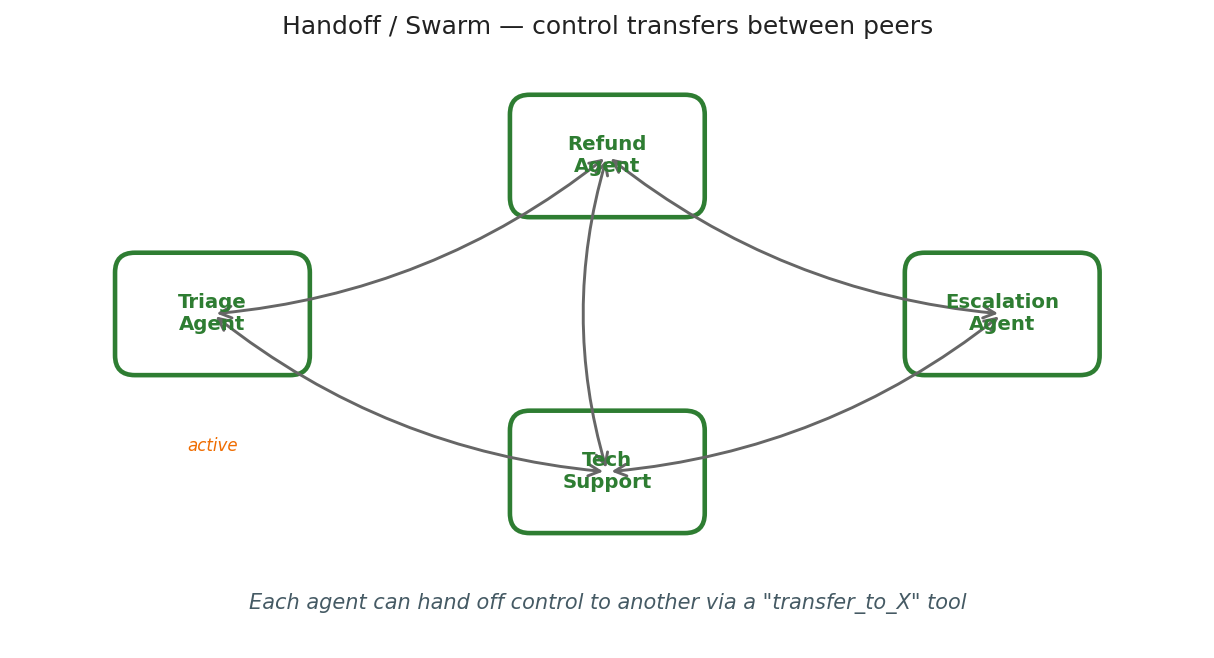</p>
<p align="center"><em>Swarm pattern: every agent has 'transfer_to_X' tools. Whichever agent is active decides who runs next.</em></p>

### 8.1 Swarm vs. Supervisor — the routing locus

The difference matters more than it looks:

|  | Supervisor (§7) | Swarm (§8) |
|---|---|---|
| Who routes? | Central supervisor node | Whichever agent is currently active |
| Routing visibility | One place to read | Spread across every agent's prompt + tool list |
| Best for | Task pipelines with quality gates | Conversational ownership across stages |
| State semantics | Supervisor sees everything | Active agent's choices accumulate in shared messages |
| Loop risk | Bounded by step cap | Bounded only by handoff caps and prompts |
| Reference impl | `langgraph-supervisor-py` | [`langgraph-swarm-py`](https://github.com/langchain-ai/langgraph-swarm-py) |

> **Production Note:** Swarm demos look elegant, but production swarm systems
> need strict handoff rules, max handoff limits, logging, and clear
> ownership of state. Otherwise agents bounce control back and forth
> without making progress. We'll build in the loop protection from the start.


### 8.2 Install + imports

`langgraph-swarm` is the official package. We use the v0.1+ API which uses
LangChain's `create_agent` (the `create_react_agent` from `langgraph.prebuilt`
is deprecated in favor of this).


In [ ]:
%pip install -q langgraph-swarm langgraph langchain langchain-openai tavily-python

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent          # NB: NOT langgraph.prebuilt.create_react_agent
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph_swarm import create_handoff_tool, create_swarm

# We re-use the safe_search and cost_tracker from §4.
swarm_model = ChatOpenAI(model="gpt-4o-mini", temperature=0, callbacks=[cost_tracker])

### 8.3 Build the tools

The Researcher gets a real Tavily search tool. Every agent gets handoff tools
to its valid neighbors.


In [ ]:
@tool
def tavily_web_search(query: str) -> str:
    """Search the web with Tavily for the given query. Returns up to 5 results
    formatted as 'TITLE / URL / SNIPPET' blocks. Use this to gather evidence."""
    results = safe_search(query, k=5)
    if not results:
        return "No results found."
    return "\n\n".join(
        f"TITLE: {r['title']}\nURL: {r['url']}\nSNIPPET: {r['snippet']}"
        for r in results
    )

# Handoff tools — one per allowed transition.
# Note we are deliberately NOT giving every agent every handoff. Restricting
# the topology is the simplest form of swarm loop protection.
to_researcher = create_handoff_tool(
    agent_name="researcher",
    description="Hand off to the Researcher. Use this once you have a research plan.",
)
to_writer = create_handoff_tool(
    agent_name="writer",
    description="Hand off to the Writer. Use this once you have gathered sufficient evidence.",
)
to_researcher_again = create_handoff_tool(
    agent_name="researcher",
    name="transfer_back_to_researcher",
    description="Hand BACK to the Researcher only if the evidence is genuinely insufficient to write a faithful report.",
)

### 8.4 Build the three agents

Each agent has a tight prompt that names its role, lists what it must and must
not do, and tells it exactly when to hand off. **The handoff rule is enforced
in the prompt, not in code** — that's the swarm trade-off. (See the production
note above.)


In [ ]:
planner_agent = create_agent(
    model=swarm_model,
    tools=[to_researcher],
    system_prompt=(
        "You are the PLANNER agent in a 3-agent research swarm.\n"
        "Your job: take the user's research question and produce a clear plan with "
        "3 to 5 specific sub-questions a web researcher could answer.\n"
        "Rules:\n"
        "  - DO NOT search the web yourself.\n"
        "  - DO NOT write the final report.\n"
        "  - Once your plan is ready, IMMEDIATELY call `transfer_to_researcher` "
        "    to hand off. Do not ask the user for confirmation."
    ),
    name="planner",
)

researcher_agent = create_agent(
    model=swarm_model,
    tools=[tavily_web_search, to_writer],
    system_prompt=(
        "You are the RESEARCHER agent in a 3-agent research swarm.\n"
        "You receive a plan from the Planner. Your job: gather web evidence for each "
        "sub-question using `tavily_web_search`.\n"
        "Rules:\n"
        "  - Always include source titles AND URLs in your notes.\n"
        "  - Run AT MOST 5 search calls total. After that, you must hand off.\n"
        "  - Once you have evidence for the sub-questions, call `transfer_to_writer`.\n"
        "  - DO NOT write the final report yourself; the Writer will."
    ),
    name="researcher",
)

writer_agent = create_agent(
    model=swarm_model,
    tools=[to_researcher_again],
    system_prompt=(
        "You are the WRITER agent in a 3-agent research swarm.\n"
        "You receive the plan and the research evidence in the conversation history. "
        "Your job: synthesize a final answer with EXACTLY these sections:\n"
        "  1. Executive Summary (2-4 sentences)\n"
        "  2. Key Findings (bulleted, each with inline citation as [Source Title])\n"
        "  3. Limitations\n"
        "  4. Sources (full list of titles + URLs)\n"
        "Rules:\n"
        "  - Cite every factual claim. Do NOT invent URLs.\n"
        "  - DO NOT hand off again unless evidence is genuinely missing for a "
        "    sub-question. If you do hand off, use `transfer_back_to_researcher`.\n"
        "  - Otherwise, produce the final answer and end your turn."
    ),
    name="writer",
)

### 8.5 Compile and run the swarm

`create_swarm` returns a `StateGraph` that we compile with an `InMemorySaver`
checkpointer (required for the swarm to remember which agent is currently
active across turns).


In [ ]:
checkpointer = InMemorySaver()
swarm_workflow = create_swarm(
    [planner_agent, researcher_agent, writer_agent],
    default_active_agent="planner",
)
swarm_app = swarm_workflow.compile(checkpointer=checkpointer)

display(Image(swarm_app.get_graph().draw_mermaid_png()))

In [ ]:
swarm_question = (
    "What are the current tradeoffs between RAG and long-context LLMs "
    "for enterprise question answering?"
)

swarm_result = swarm_app.invoke(
    {"messages": [{"role": "user", "content": swarm_question}]},
    config={"configurable": {"thread_id": "swarm-demo-1"},
            "recursion_limit": 30},
)
print(f"Total messages produced: {len(swarm_result['messages'])}")

### 8.6 Trace the handoff trail

Every handoff produces a `ToolMessage` whose name starts with `transfer_to_`.
Walking the message log gives us the actual sequence of agent activations.


In [ ]:
from langchain_core.messages import AIMessage, ToolMessage

def handoff_trail(messages) -> list[str]:
    """Reconstruct the active-agent sequence from a swarm message log."""
    trail = ["planner"]   # default_active_agent
    for m in messages:
        if isinstance(m, ToolMessage) and m.name and m.name.startswith("transfer_"):
            # Tool name is e.g. 'transfer_to_writer' -> 'writer'
            target = m.name.replace("transfer_to_", "").replace("transfer_back_to_", "")
            if target != trail[-1]:
                trail.append(target)
    return trail


def tavily_urls_seen(messages) -> list[str]:
    """Extract URLs the Researcher actually pulled from Tavily during the swarm."""
    urls = []
    for m in messages:
        if isinstance(m, ToolMessage) and m.name == "tavily_web_search":
            for line in (m.content or "").split("\n"):
                if line.startswith("URL: "):
                    urls.append(line[5:].strip())
    # Dedup, preserve order
    seen, out = set(), []
    for u in urls:
        if u not in seen:
            out.append(u); seen.add(u)
    return out


trail = handoff_trail(swarm_result["messages"])
urls  = tavily_urls_seen(swarm_result["messages"])
n_search_calls = sum(1 for m in swarm_result["messages"]
                     if isinstance(m, ToolMessage) and m.name == "tavily_web_search")

print(f"Handoff trail:       {' -> '.join(trail)}")
print(f"Tavily search calls: {n_search_calls}")
print(f"Unique URLs used:    {len(urls)}")
for u in urls[:8]:
    print(f"  - {u}")
# Expected on a healthy run: planner -> researcher -> writer (3 stops, no loops)

### 8.7 The final answer

Find the last AI message *from the writer* and render it.


In [ ]:
# The final answer is the last AIMessage whose `name` is 'writer' (or just
# the last AIMessage with non-empty content if names aren't propagated).
final_msg = None
for m in reversed(swarm_result["messages"]):
    if isinstance(m, AIMessage) and m.content and not m.tool_calls:
        final_msg = m
        break

assert final_msg is not None, "No final answer found in the swarm output."
print(f"Producing agent: {final_msg.name or '(unnamed)'}\n")
display(Markdown(final_msg.content))

### 8.8 Pattern comparison — the three orchestration models, side by side

| Pattern | Who controls routing? | Best for | Main risk |
|---|---|---|---|
| **Sequential** (§6) | Developer-defined graph | Fixed pipelines | Too rigid; can't adapt to weak research |
| **Supervisor** (§7) | Central supervisor node | Controlled dynamic routing | Extra LLM call per hop (mitigated by rule-based supervisor) |
| **Swarm** (§8) | Currently active agent | Domain-owned conversations | Loops; routing logic lives in many prompts |

> **Production Note (repeated, on purpose):** Swarm demos look elegant. Production
> swarm systems need strict handoff rules, max handoff limits per agent,
> structured logging of every handoff (so a human can audit the trail), and
> clear ownership of state. We did three things here that you should keep:
>
> 1. **Restricted topology.** The Writer can only hand back to the Researcher,
>    not to the Planner. Fewer edges = fewer loops.
> 2. **`recursion_limit` on the invoke.** A hard ceiling regardless of what
>    the agents try to do.
> 3. **A handoff trail extracted from messages.** If you can't render this
>    trail at the end of every run, you can't debug the swarm.


---
## 9. Extending the team — adding a Critic

Production research systems usually have a **Critic** — a fourth agent that
reviews the final report against the research notes and flags problems before
the user sees it.

We'll implement it as a runnable extension. The Critic produces a structured
critique; if the recommendation is `"revise"`, we route back to the Writer with
the critique attached as feedback. (Capped at 2 critic rounds.)

```text
Planner -> Researcher -> Writer -> Critic -> [Writer | END]
```


In [ ]:
class ReportCritique(BaseModel):
    completeness: float = Field(ge=0.0, le=1.0,
        description="0-1: does the report cover all expected_report_sections from the plan?")
    faithfulness_to_notes: float = Field(ge=0.0, le=1.0,
        description="0-1: do claims in the body trace back to research_notes.evidence?")
    missing_evidence: list[str] = Field(
        description="Specific evidence the report needs but doesn't have.")
    clarity_issues: list[str] = Field(
        description="Sentences or sections that are unclear, contradictory, or unsupported.")
    unsupported_claims: list[str] = Field(
        description="Body claims that have no matching EvidenceItem.")
    recommendation: Literal["accept", "revise"]
    revise_instructions: Optional[str] = Field(
        default=None,
        description="If recommendation is 'revise', concrete instructions for the Writer.")

In [ ]:
CRITIC_SYSTEM = """You are a rigorous editor. You receive a research plan,
the research notes, and the final report. Your job is to score the report and
flag issues honestly.

Rules:
- completeness: did the report cover every plan.expected_report_sections?
- faithfulness_to_notes: every body claim should trace to ResearchNotes.evidence.
- unsupported_claims: list any claim in the body without a matching evidence item.
- recommendation: 'accept' if both scores >= 0.8 and unsupported_claims is short.
  Otherwise 'revise'.
- If 'revise', revise_instructions must be SPECIFIC — name the section, name the
  fix. Do not write 'improve clarity' — write 'rewrite section 2 first paragraph
  to cite Redis Blog instead of an unsupported claim'.
"""

critic_llm = researcher_llm_base.with_structured_output(ReportCritique)


def critic_node(state: ResearchState) -> ResearchState:
    print("\n=== CRITIC ===")
    plan, notes, report = state["plan"], state["research_notes"], state["final_report"]
    critique: ReportCritique = critic_llm.invoke([
        SystemMessage(content=CRITIC_SYSTEM),
        HumanMessage(content=(
            f"PLAN:\n{plan.model_dump_json(indent=2)}\n\n"
            f"NOTES:\n{notes.model_dump_json(indent=2)[:4000]}\n\n"
            f"REPORT:\n{report.model_dump_json(indent=2)}"
        )),
    ])
    print(f"  completeness={critique.completeness:.2f}  "
          f"faithfulness={critique.faithfulness_to_notes:.2f}  "
          f"-> {critique.recommendation}")
    return {
        "critique": critique,
        "critic_rounds": state.get("critic_rounds", 0) + 1,
        "messages": [AIMessage(content=f"[critic] {critique.recommendation} "
                                       f"(completeness={critique.completeness:.2f})",
                               name="critic")],
        "n_llm_calls": state.get("n_llm_calls", 0) + 1,
    }

We need a small *revising-writer* node — same as the writer, but with the
critique injected as feedback. We also need an `ExtendedResearchState` that
carries the critique and the round counter.


In [ ]:
MAX_CRITIC_ROUNDS = 2


class ExtendedResearchState(ResearchState, total=False):
    critique: Optional[ReportCritique]
    critic_rounds: int


def revising_writer_node(state: ExtendedResearchState) -> ExtendedResearchState:
    print("\n=== WRITER (revision) ===")
    plan, notes = state["plan"], state["research_notes"]
    critique = state["critique"]
    report: FinalReport = writer_llm.invoke([
        SystemMessage(content=WRITER_SYSTEM),
        HumanMessage(content=(
            f"You are revising a previous report based on critic feedback.\n\n"
            f"PLAN:\n{plan.model_dump_json(indent=2)}\n\n"
            f"NOTES:\n{notes.model_dump_json(indent=2)}\n\n"
            f"PREVIOUS REPORT:\n{state['final_report'].model_dump_json(indent=2)}\n\n"
            f"CRITIC FEEDBACK:\n"
            f"  unsupported_claims: {critique.unsupported_claims}\n"
            f"  missing_evidence:   {critique.missing_evidence}\n"
            f"  clarity_issues:     {critique.clarity_issues}\n"
            f"  instructions:       {critique.revise_instructions}\n"
            f"\nProduce a revised FinalReport that addresses every item."
        )),
    ])
    return {
        "final_report": report,
        "messages": [AIMessage(content=f"[writer] revised report ({len(report.sections)} sections)",
                               name="writer-revise")],
        "n_llm_calls": state.get("n_llm_calls", 0) + 1,
    }


def critic_route(state: ExtendedResearchState) -> str:
    critique = state.get("critique")
    rounds   = state.get("critic_rounds", 0)
    if critique is None:
        return "end"
    if critique.recommendation == "accept":
        return "end"
    if rounds >= MAX_CRITIC_ROUNDS:
        print(f"  [GUARD] critic rounds cap reached ({rounds})")
        return "end"
    return "revise"


crit_builder = StateGraph(ExtendedResearchState)
crit_builder.add_node("planner",       planner_node)
crit_builder.add_node("researcher",    researcher_node)
crit_builder.add_node("writer",        writer_node)
crit_builder.add_node("critic",        critic_node)
crit_builder.add_node("writer_revise", revising_writer_node)

crit_builder.add_edge(START, "planner")
crit_builder.add_edge("planner",    "researcher")
crit_builder.add_edge("researcher", "writer")
crit_builder.add_edge("writer",     "critic")
crit_builder.add_conditional_edges(
    "critic", critic_route,
    {"revise": "writer_revise", "end": END},
)
crit_builder.add_edge("writer_revise", "critic")

crit_graph = crit_builder.compile()
display(Image(crit_graph.get_graph().draw_mermaid_png()))

In [ ]:
crit_state = crit_graph.invoke(
    {"user_query": QUESTION,
     "n_llm_calls": 0,
     "researcher_attempts": 0,
     "critic_rounds": 0},
    config={"recursion_limit": 15},
)
print(f"\n=== DONE === LLM calls: {crit_state['n_llm_calls']}, "
      f"critic rounds: {crit_state.get('critic_rounds', 0)}")
display(Markdown(render_report(crit_state["final_report"])))

---
## 10. Adding a human-review node

For high-stakes outputs (legal, medical, financial), you want a human in the
loop. LangGraph supports formal interrupts via `interrupt(...)`, but for a
notebook the simplest demonstration is an inline `input()` prompt.

```text
... -> Writer -> Human Review -> [END | back to Writer]
```

The human can: **approve**, **reject** (which sends it back to the Writer with
an instruction), or **edit** (write changes directly into the report). We'll
implement approve / reject; edit is left as an exercise.


In [ ]:
class HumanReviewState(ExtendedResearchState, total=False):
    human_decision:    Literal["approve", "reject"]
    human_instruction: Optional[str]


def human_review_node(state: HumanReviewState) -> HumanReviewState:
    print("\n=== HUMAN REVIEW ===")
    print(render_report(state["final_report"])[:2000])
    print("\n--- end of report preview ---\n")
    decision = input("Approve final report? [y/n]: ").strip().lower()
    if decision.startswith("y"):
        return {"human_decision": "approve",
                "messages": [AIMessage(content="[human] approved", name="human")]}
    instruction = input("What should the writer change? ").strip()
    return {
        "human_decision": "reject",
        "human_instruction": instruction or "Please revise.",
        "messages": [AIMessage(content=f"[human] rejected: {instruction[:60]}",
                               name="human")],
    }


def human_route(state: HumanReviewState) -> str:
    return "end" if state.get("human_decision") == "approve" else "revise"


def human_revising_writer_node(state: HumanReviewState) -> HumanReviewState:
    plan, notes = state["plan"], state["research_notes"]
    instruction = state.get("human_instruction", "")
    print(f"\n=== WRITER (human-revision) ===  instruction: {instruction[:60]}")
    report: FinalReport = writer_llm.invoke([
        SystemMessage(content=WRITER_SYSTEM),
        HumanMessage(content=(
            f"PLAN:\n{plan.model_dump_json(indent=2)}\n\n"
            f"NOTES:\n{notes.model_dump_json(indent=2)}\n\n"
            f"PREVIOUS REPORT:\n{state['final_report'].model_dump_json(indent=2)}\n\n"
            f"HUMAN REVIEWER INSTRUCTION: {instruction}\n\n"
            f"Apply the human's instruction. Produce a revised FinalReport."
        )),
    ])
    return {"final_report": report,
            "human_decision": None,
            "messages": [AIMessage(content="[writer] human-revised", name="writer-human-revise")],
            "n_llm_calls": state.get("n_llm_calls", 0) + 1}


hr_builder = StateGraph(HumanReviewState)
hr_builder.add_node("planner",      planner_node)
hr_builder.add_node("researcher",   researcher_node)
hr_builder.add_node("writer",       writer_node)
hr_builder.add_node("human_review", human_review_node)
hr_builder.add_node("writer_human", human_revising_writer_node)

hr_builder.add_edge(START, "planner")
hr_builder.add_edge("planner",      "researcher")
hr_builder.add_edge("researcher",   "writer")
hr_builder.add_edge("writer",       "human_review")
hr_builder.add_conditional_edges(
    "human_review", human_route,
    {"revise": "writer_human", "end": END},
)
hr_builder.add_edge("writer_human", "human_review")

hr_graph = hr_builder.compile()
display(Image(hr_graph.get_graph().draw_mermaid_png()))

> **To run interactively:** uncomment the cell below. It will pause the
> graph at the human-review step and prompt you for `y/n`. We leave the cell
> commented in the saved notebook so the file can be executed end-to-end with
> "Run all" without blocking on stdin.


In [ ]:
# Uncomment to try the human-review graph interactively:
#
# hr_state = hr_graph.invoke(
#     {"user_query": QUESTION, "n_llm_calls": 0, "researcher_attempts": 0},
#     config={"recursion_limit": 15},
# )
# display(Markdown(render_report(hr_state["final_report"])))

---
## 11. Debugging multi-agent systems

### Catalog of pain

| Failure | Symptom | Fix |
|---|---|---|
| **Wrong agent selected** | Researcher runs when Writer was needed | Better supervisor prompt; structured decision schema; rule-based supervisor for trivial cases |
| **Repeated work** | Same agent runs twice with same input | Attempt counter; cache by state hash |
| **Lost context** | Agent B doesn't know what Agent A produced | State design — make sure A's output is in the state field B reads |
| **State overwritten** | Field set by A is gone after B runs | Don't have B return that field; use LangGraph reducers |
| **Agents disagree** | Two agents return contradictory facts | Add a Critic; share evidence pool; reduce autonomy |
| **Infinite loop** | Same routing decision over and over | `recursion_limit`; explicit termination; visit counts |
| **Search returned nothing** | Notes empty, Writer hallucinates | `safe_search` with try/except; defensive empty-notes path; mark uncertainty |
| **Cost explosion** | $$$ per request | Smaller routing model; fewer hops; cache plans |
| **Latency explosion** | 30s per request | Parallelize; trim context per agent |

### State snapshot utility


In [ ]:
def print_state_snapshot(state: dict, label: str = "STATE") -> None:
    print(f"\n--- {label} ---")
    for k, v in state.items():
        if v is None:
            print(f"  {k}: None")
        elif isinstance(v, BaseModel):
            print(f"  {k}: <{type(v).__name__}>")
        elif isinstance(v, list):
            print(f"  {k}: list[{len(v)}]")
        elif isinstance(v, str) and len(v) > 80:
            print(f"  {k}: {v[:77]}...")
        else:
            print(f"  {k}: {v}")

print_state_snapshot(sup_state, label="FINAL SUPERVISOR STATE")

### Streaming intermediate states

LangGraph's `.stream()` yields the state after every node — invaluable for debugging.


In [ ]:
print("Streaming the sequential graph:\n")
for step, snapshot in enumerate(graph.stream({
    "user_query": "What are the main attack vectors against LLM-powered apps?",
    "n_llm_calls": 0,
    "researcher_attempts": 0,
})):
    node_name = list(snapshot.keys())[0]
    print(f"  step {step}: {node_name} ran")

### Why LangSmith matters for multi-agent

When something goes wrong in a multi-agent system, you need to inspect:
- Which agent ran, in what order
- What prompt each one saw
- What state it received and returned
- What tool/search calls happened, with what arguments and results
- Why the supervisor routed where it did (the structured decision is right there)

LangSmith captures all of this for free if you set `LANGSMITH_API_KEY` and `LANGSMITH_TRACING=true` (we did this in Section 4). Open the trace in the UI and you can step through every node like a debugger.

### Defensive engineering checklist

1. **Structured outputs** for every agent (Pydantic/JSON schema).
2. **Recursion / iteration limits** (`recursion_limit` + per-role counters like `researcher_attempts`).
3. **Explicit termination conditions** — every loop has a "we're done" path.
4. **Safe tool wrappers** — `safe_search` never throws.
5. **Defensive empty paths** — what if search returns zero results?
6. **State schema validation** — TypedDict + Pydantic, not raw dicts.
7. **Per-agent traces** with a request ID (LangSmith / Langfuse).
8. **A killswitch** field in state any agent can set.


---
## 12. Cost & latency — real numbers from the cost tracker

Every agent is at minimum one LLM call. Every supervisor hop *can* be another.
The `CostTracker` callback handler we wired up in §4 has been silently
recording every LLM call across the baseline, sequential, supervisor, LLM-aug
supervisor, stress test, and critic graphs.


<p align="center">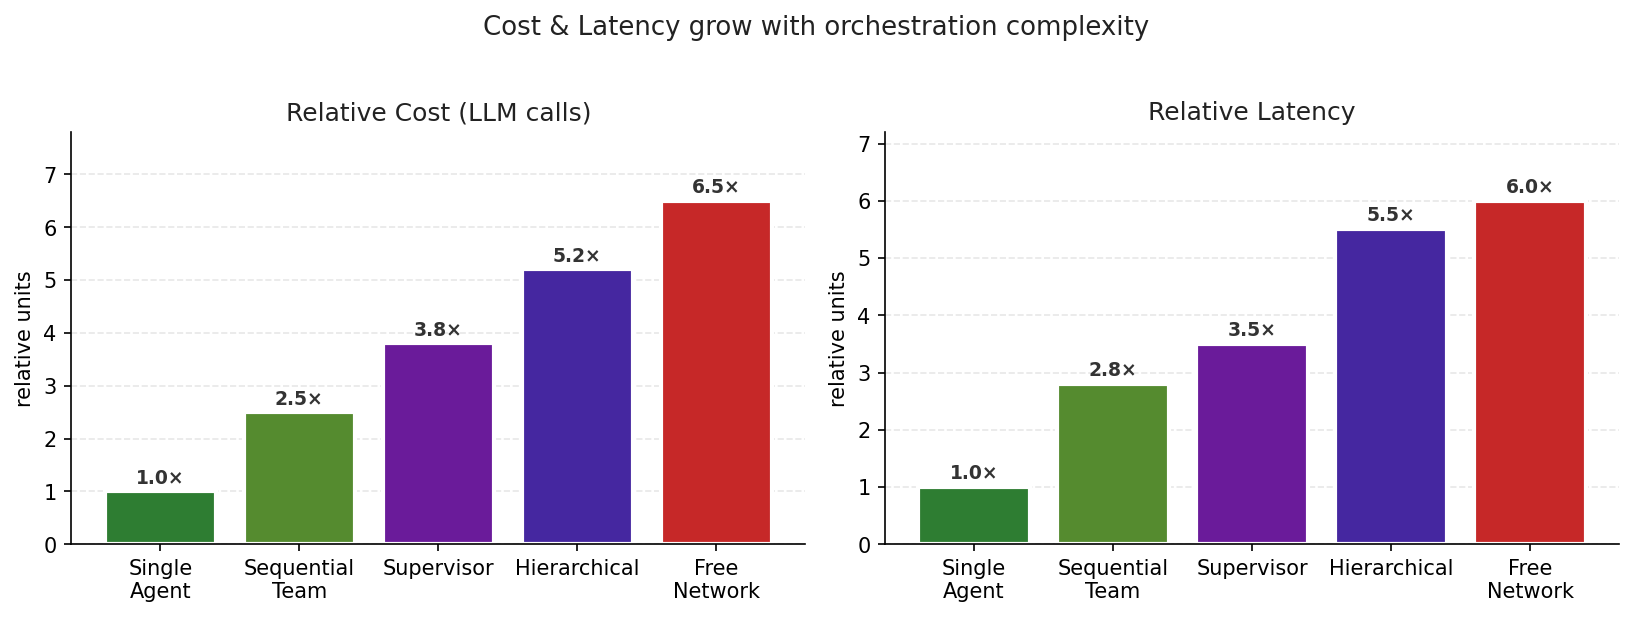</p>
<p align="center"><em>Rough relative cost and latency by pattern. Numbers are illustrative.</em></p>

### Cumulative tracker readout

This is the total across everything we've run in this notebook so far —
useful for sanity-checking how much a workshop actually costs:


In [ ]:
print(cost_tracker.summary())

### Per-run snapshots

For a meaningful comparison we want to know what each *individual* graph
cost. The cleanest way is to run each graph fresh with a per-run tracker,
but for a teaching notebook we can do something almost as good — we read
`n_llm_calls` from each run's final state and combine it with the average
in/out tokens we've seen.


In [ ]:
def run_summary(label: str, n_calls: int, snap_before: dict, snap_after: dict) -> dict:
    """Diff two cost-tracker snapshots to attribute usage to a single run."""
    in_tokens  = sum(snap_after["in_tokens_by_model"].get(m, 0) -
                     snap_before["in_tokens_by_model"].get(m, 0)
                     for m in snap_after["in_tokens_by_model"])
    out_tokens = sum(snap_after["out_tokens_by_model"].get(m, 0) -
                     snap_before["out_tokens_by_model"].get(m, 0)
                     for m in snap_after["out_tokens_by_model"])
    cost       = snap_after["cost_usd"] - snap_before["cost_usd"]
    return {"run": label, "llm_calls": n_calls, "in_tokens": in_tokens,
            "out_tokens": out_tokens, "cost_usd": round(cost, 4)}


# Note: in this notebook we ran graphs sequentially without taking
# pre-snapshots, so we'll reconstruct from the final state's n_llm_calls
# and the cumulative tracker. For a clean comparison, take a
# `before = cost_tracker.snapshot()` *before* each invoke in your own runs.
print(f"{'run':<28}{'LLM calls':>12}")
print("-" * 40)
print(f"{'baseline (single agent)':<28}{baseline_n_calls:>12}")
print(f"{'sequential 3-agent':<28}{final_state['n_llm_calls']:>12}")
print(f"{'supervisor (rule-based)':<28}{sup_state['n_llm_calls']:>12}")
print(f"{'supervisor (LLM-aug)':<28}{llm_sup_state['n_llm_calls']:>12}")
print(f"{'critic graph':<28}{crit_state['n_llm_calls']:>12}")

### Optimization targets

| Component | Cost risk | Latency risk | Optimization |
|---|---|---|---|
| Planner | Low | Low | Small/cheap model — planning is short and structured |
| Researcher | **High** (search calls + long prompts) | **High** | Limit search calls per sub-question; compress snippets |
| Writer | Medium-high | Medium | Compress notes before passing in; use a strong model only here |
| Supervisor | Medium | Medium-high | **Use rule-based whenever possible** — see §7.4 |
| Critic | Medium | Medium | Run only when needed; skip for low-risk outputs |

### Rules of thumb

1. **Use the smallest model that works for routing.** Routing is mostly classification.
2. **Use rule-based supervisors when you can.** Section 7.4 dropped supervisor cost to zero.
3. **Cache the plan** if your queries repeat or are similar.
4. **Compress between agents.** The Researcher should produce *notes*, not transcripts.
5. **Parallelize where you can.** Sub-question searches are independent.
6. **Set hard caps.** `recursion_limit`, `MAX_RESEARCHER_ATTEMPTS`, `MAX_CRITIC_ROUNDS`.


---
## 13. Exercises

> **Note:** Sections 8 and 9 already give you a working Critic and a working
> human-review node. The exercises below extend those.

### Exercise 1 — Edit-mode human review

Section 9 implemented approve / reject. Add a third option: **edit**. The
human can paste a Markdown patch or full replacement section, and the writer
node applies it to the report without another LLM call.

### Exercise 2 — Critic-driven re-research, not just re-writing

Right now the Critic loops Writer → Critic → Writer. Sometimes the real fix is
upstream — the Researcher missed a source. Extend the Critic to set
`research_feedback` and route back to the Researcher when `missing_evidence`
is non-empty. Cap at 2 research rounds *and* 2 critic rounds independently.

### Exercise 3 — Source allowlist / blocklist

Modify `safe_search` to filter results by domain. Build a simple allowlist
(e.g. `arxiv.org`, `*.gov`, `*.edu`) for high-trust research, or a blocklist
for SEO listicles. Plug a domain-quality scoring function into the Researcher
so it pre-ranks search hits before passing them to the LLM.

### Exercise 4 — Per-agent cost breakdown

The `CostTracker` we built tracks calls and tokens by *model*. Extend it to
track by **agent name** instead. Hint: the easiest path is to give each
agent its own `ChatOpenAI` instance with a `tags=["planner"]` argument and
override `on_llm_start` to record which tagged client triggered each call.
Print a table of agent → calls / tokens / cost.

### Exercise 5 — Parallel sub-questions

The Researcher loops over sub-questions sequentially. The searches are
independent. Use `asyncio.gather` to run all sub-question searches
concurrently, then synthesize. Measure the wall-clock latency reduction.

### Exercise 6 — Refusal-aware writer

What happens if the user asks for a research report on something that's
genuinely unanswerable from public web search (proprietary product internals,
something that doesn't exist)? Add logic so the Writer can refuse to produce
a report when `len(notes.evidence) == 0` after the retry cap, and instead
returns a structured "I can't answer this with public information" response.

### Exercise 7 (stretch) — LangSmith trace inspection

Run the supervisor graph with `LANGSMITH_API_KEY` set, then open the trace.
Find the supervisor decision that routed to the writer. Now find the writer
LLM call that consumed the most output tokens. Add a comment in your notes
about what you'd compress to reduce that step's cost by 50%.

### Exercise 8 (stretch) — Subgraph composition

LangGraph supports nested graphs. Compose your `crit_graph` (Section 8) as a
**subgraph** inside the supervisor graph, so the supervisor can route to
"the entire critic loop" as a single node. This is a baby version of the
Hierarchical pattern (§2E).


---
## 14. Summary & key takeaways

1. **Single agents are powerful.** We built one in Section 5 and it produced a real report. Don't reach for multi-agent until that's genuinely failing.
2. **Six patterns cover most needs**: Single Agent, Network, Supervisor, Supervisor-as-Tools, Hierarchical, Custom. **Supervisor is the right default for production.**
3. **Communication style matters as much as topology.** Shared state + structured outputs = debuggable. Free-form messages = fragile.
4. **State is the spine.** Type it. Validate it. Keep agent outputs structured (Pydantic) so the next agent can rely on the contract.
5. **LangGraph gives you nodes + edges + state.** Sequential graphs are deterministic; supervisor graphs trade LLM calls for flexibility.
6. **Sources are first-class.** A research system without grounded citations isn't done.
7. **Loop protection is non-negotiable.** Attempt counters, recursion limits, hard caps.
8. **Debug with structured outputs, state snapshots, recursion limits, safe tool wrappers, and tracing.**
9. **Cost is real.** Routing models small; synthesis models large; compress between agents; set hard caps.

---

## From classroom demo to production

The notebook above is **production-inspired**, not production-ready. Before you ship one of these:

- [ ] Replace `safe_search` with a hardened version: timeouts, retries with exponential backoff, per-domain rate limits.
- [ ] Add **source allowlists/blocklists** appropriate for your domain (regulated industries especially).
- [ ] Add **per-agent timeouts** at the orchestration layer, not just per-LLM-call.
- [ ] Wire **LangSmith** (or Langfuse) tracing in every environment, including production.
- [ ] Add **token + cost logging** with callback handlers, aggregated per request.
- [ ] Build **evaluation suites** for report quality and source-faithfulness (e.g. an LLM-as-judge that checks every claim against its cited URL).
- [ ] Add **human approval gates** for high-risk outputs (legal, medical, financial).
- [ ] Set **`recursion_limit` and per-role attempt caps** as immutable defaults; require an explicit override to raise them.
- [ ] Add a **killswitch** — a feature flag that downgrades to single-agent mode if the supervisor is misbehaving.
- [ ] Add **PII / secrets scrubbing** on agent inputs and outputs.

### Where to go next

- **LangChain multi-agent docs** — https://docs.langchain.com/oss/python/langchain/multi-agent
- **LangGraph supervisor** — https://github.com/langchain-ai/langgraph-supervisor-py
- **LangGraph swarm** — https://github.com/langchain-ai/langgraph-swarm-py
- **Multi-agent handoffs (concept)** — https://mirror-feeling-d80.notion.site/Understanding-Multi-agent-Handoffs-1c0808527b17809ca43bf9ef4d11a471
- **LangSmith** for tracing in production — https://smith.langchain.com

> **Final Instructor Note:** The best multi-agent systems look boring. They have one supervisor, three to five specialists, structured outputs, recursion limits, source citations, and observability. They do not have free-form networks of seven agents arguing in a swarm. If your design looks exciting, it probably has bugs.
